# IndusCredit Loan Default Risk Assessment
---
## Section 1: Imports & Config

In [1]:
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy',
            'scikit-learn', 'xgboost', 'lightgbm', 'shap', 'joblib']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             roc_curve, precision_recall_curve, classification_report,
                             confusion_matrix)

import xgboost as xgb
import lightgbm as lgb
import shap
import joblib
import os, warnings

warnings.filterwarnings('ignore')

# ── Global config ──
SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
PALETTE = sns.color_palette('Set2')
DEFAULT_COLORS = {0: PALETTE[0], 1: PALETTE[1]}

# ── Output directories ──
for d in ['outputs/plots', 'outputs/shap', 'outputs/predictions', 'outputs/model']:
    os.makedirs(d, exist_ok=True)

print("✅ All imports and config done.")

✅ All imports and config done.


---
## Section 2: Data Loading & Quality Audit

In [10]:
# ── Load data ──
df_train = pd.read_csv('/content/loan_train.csv', parse_dates=['application_date'])
df_test  = pd.read_csv('/content/loan_test.csv',  parse_dates=['application_date'])

TEST_HAS_TARGET = 'default_flag' in df_test.columns
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"Test has default_flag: {TEST_HAS_TARGET}")

Train shape: (8000, 24)
Test shape:  (2500, 23)
Test has default_flag: False


In [11]:
# ── Basic info ──
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n{'='*60}")
    print(f"  {label} — Shape: {df.shape}, Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print(f"{'='*60}")
    print("\nDtypes:")
    print(df.dtypes.to_string())
    print("\nNull counts (count | %%):")
    nulls = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(2)
    null_df = pd.DataFrame({'count': nulls, 'pct': null_pct})
    print(null_df[null_df['count'] > 0].to_string() if null_df['count'].sum() > 0 else "  No nulls found.")

    # Duplicate loan_id
    dups = df['loan_id'].duplicated().sum()
    print(f"\nDuplicate loan_ids: {dups}")
    if dups > 0:
        df.drop_duplicates(subset='loan_id', inplace=True)
        print(f"  → Dropped duplicates. New shape: {df.shape}")


  TRAIN — Shape: (8000, 24), Memory: 4.7 MB

Dtypes:
loan_id                                object
application_date               datetime64[ns]
age                                     int64
gender                                 object
education                              object
state                                  object
urban_rural                            object
employment_type                        object
employment_years                        int64
annual_income_inr                       int64
loan_type                              object
loan_purpose                           object
loan_amount_inr                         int64
loan_tenure_months                      int64
interest_rate_pct                     float64
credit_score                            int64
num_existing_loans                      int64
dti_ratio                             float64
ltv_ratio                             float64
has_collateral                          int64
bureau_enquiries_6m       

In [12]:
# ── Value range validation ──
range_checks = {
    'age':          (21, 65),
    'credit_score': (550, 900),
    'dti_ratio':    (0.0, 0.65),
}

for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n── Range Validation: {label} ──")
    for col, (lo, hi) in range_checks.items():
        if col not in df.columns:
            continue
        violations = ((df[col] < lo) | (df[col] > hi)).sum()
        print(f"  {col} [{lo}–{hi}]: {violations} violations ({violations/len(df)*100:.2f}%)")


── Range Validation: TRAIN ──
  age [21–65]: 0 violations (0.00%)
  credit_score [550–900]: 0 violations (0.00%)
  dti_ratio [0.0–0.65]: 0 violations (0.00%)

── Range Validation: TEST ──
  age [21–65]: 0 violations (0.00%)
  credit_score [550–900]: 0 violations (0.00%)
  dti_ratio [0.0–0.65]: 0 violations (0.00%)


In [13]:
# ── Categorical columns: unique values ──
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
# remove date if still object
cat_cols = [c for c in cat_cols if c != 'application_date']

for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n── Categorical uniques: {label} ──")
    for col in cat_cols:
        if col in df.columns:
            print(f"  {col}: {sorted(df[col].dropna().unique())}")

# Check for categories in test absent from train
print("\n── Categories in TEST but not in TRAIN ──")
for col in cat_cols:
    if col in df_test.columns and col in df_train.columns:
        unseen = set(df_test[col].dropna().unique()) - set(df_train[col].dropna().unique())
        if unseen:
            print(f"  ⚠ {col}: {unseen}")
        else:
            print(f"  ✓ {col}: all categories seen in train")


── Categorical uniques: TRAIN ──
  loan_id: ['LN0000003', 'LN0000005', 'LN0000006', 'LN0000011', 'LN0000013', 'LN0000016', 'LN0000018', 'LN0000021', 'LN0000027', 'LN0000028', 'LN0000030', 'LN0000032', 'LN0000033', 'LN0000034', 'LN0000036', 'LN0000042', 'LN0000043', 'LN0000046', 'LN0000053', 'LN0000054', 'LN0000055', 'LN0000058', 'LN0000060', 'LN0000062', 'LN0000063', 'LN0000064', 'LN0000065', 'LN0000066', 'LN0000068', 'LN0000069', 'LN0000070', 'LN0000071', 'LN0000072', 'LN0000076', 'LN0000077', 'LN0000080', 'LN0000081', 'LN0000085', 'LN0000086', 'LN0000087', 'LN0000088', 'LN0000091', 'LN0000092', 'LN0000093', 'LN0000095', 'LN0000096', 'LN0000097', 'LN0000100', 'LN0000101', 'LN0000102', 'LN0000103', 'LN0000104', 'LN0000105', 'LN0000109', 'LN0000110', 'LN0000112', 'LN0000114', 'LN0000119', 'LN0000120', 'LN0000121', 'LN0000122', 'LN0000123', 'LN0000125', 'LN0000128', 'LN0000130', 'LN0000132', 'LN0000133', 'LN0000135', 'LN0000136', 'LN0000137', 'LN0000138', 'LN0000141', 'LN0000147', 'LN00

In [14]:
# ── LTV ratio nulls cross-tab with loan_type ──
print("── LTV Ratio nulls vs Loan Type ──")
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n{label}:")
    ct = pd.crosstab(df['loan_type'], df['ltv_ratio'].isnull(), margins=True,
                     margins_name='Total')
    ct.columns = ['LTV Present', 'LTV Missing', 'Total']
    print(ct.to_string())

    # Check if any home-loan row has null LTV
    if 'Home Loan' in df['loan_type'].values:
        home_null = df[(df['loan_type'] == 'Home Loan') & df['ltv_ratio'].isnull()].shape[0]
        if home_null > 0:
            print(f"  ⚠ {home_null} Home Loan rows have missing LTV — true missingness!")
        else:
            print("  ✓ All Home Loan rows have LTV values.")

── LTV Ratio nulls vs Loan Type ──

TRAIN:
                LTV Present  LTV Missing  Total
loan_type                                      
Auto_Loan                 0         1342   1342
Education_Loan            0         1317   1317
Gold_Loan                 0         1280   1280
Home_Loan              1417            0   1417
MSME_Loan                 0         1366   1366
Personal_Loan             0         1278   1278
Total                  1417         6583   8000

TEST:
                LTV Present  LTV Missing  Total
loan_type                                      
Auto_Loan                 0          437    437
Education_Loan            0          420    420
Gold_Loan                 0          390    390
Home_Loan               431            0    431
MSME_Loan                 0          417    417
Personal_Loan             0          405    405
Total                   431         2069   2500


In [15]:
# ── Class balance ──
print("── Default Flag Distribution ──")
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    if 'default_flag' in df.columns:
        vc = df['default_flag'].value_counts().sort_index()
        pct = (vc / len(df) * 100).round(2)
        print(f"\n{label}:")
        for v in vc.index:
            print(f"  Class {v}: {vc[v]:>5d} ({pct[v]:.2f}%)")
    else:
        print(f"\n{label}: default_flag NOT present")

── Default Flag Distribution ──

TRAIN:
  Class 0:  5772 (72.15%)
  Class 1:  2228 (27.85%)

TEST: default_flag NOT present


In [16]:
# ── Outlier scan ──
outlier_cols = ['annual_income_inr', 'loan_amount_inr', 'savings_account_balance_inr',
                'employment_years', 'bureau_enquiries_6m', 'missed_payments_2y']

rows = []
for col in outlier_cols:
    if col not in df_train.columns:
        continue
    q1, q3 = df_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    below = (df_train[col] < lo).sum()
    above = (df_train[col] > hi).sum()
    rows.append({'Feature': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                 'Lower Bound': lo, 'Upper Bound': hi,
                 'Below': below, 'Above': above,
                 'Total Outliers': below + above})

outlier_df = pd.DataFrame(rows)
print("── Outlier Scan (Train, 1.5×IQR) ──")
print(outlier_df.to_string(index=False))

── Outlier Scan (Train, 1.5×IQR) ──
                    Feature         Q1         Q3        IQR  Lower Bound  Upper Bound  Below  Above  Total Outliers
          annual_income_inr  936003.75 2319622.00 1383618.25 -1139423.625  4395049.375      0      0               0
            loan_amount_inr 1253557.75 3745354.25 2491796.50 -2484137.000  7483049.000      0      0               0
savings_account_balance_inr  129193.50  376441.50  247248.00  -241678.500   747313.500      0      0               0
           employment_years       6.00      22.00      16.00      -18.000       46.000      0      0               0
        bureau_enquiries_6m       2.00       6.00       4.00       -4.000       12.000      0      0               0
         missed_payments_2y       0.00       2.00       2.00       -3.000        5.000      0     92              92


### Data Quality Summary

*Key findings are printed above. Review the outputs for:*
- Any null columns and their patterns
- Range violations in age, credit_score, dti_ratio
- LTV nulls alignment with non-home-loan rows
- Class imbalance ratio
- Outlier counts (no rows dropped — capping in Section 4)

---
## Section 3: Exploratory Data Analysis

### 3.1 — Default Rates by Category (Task 1.1)

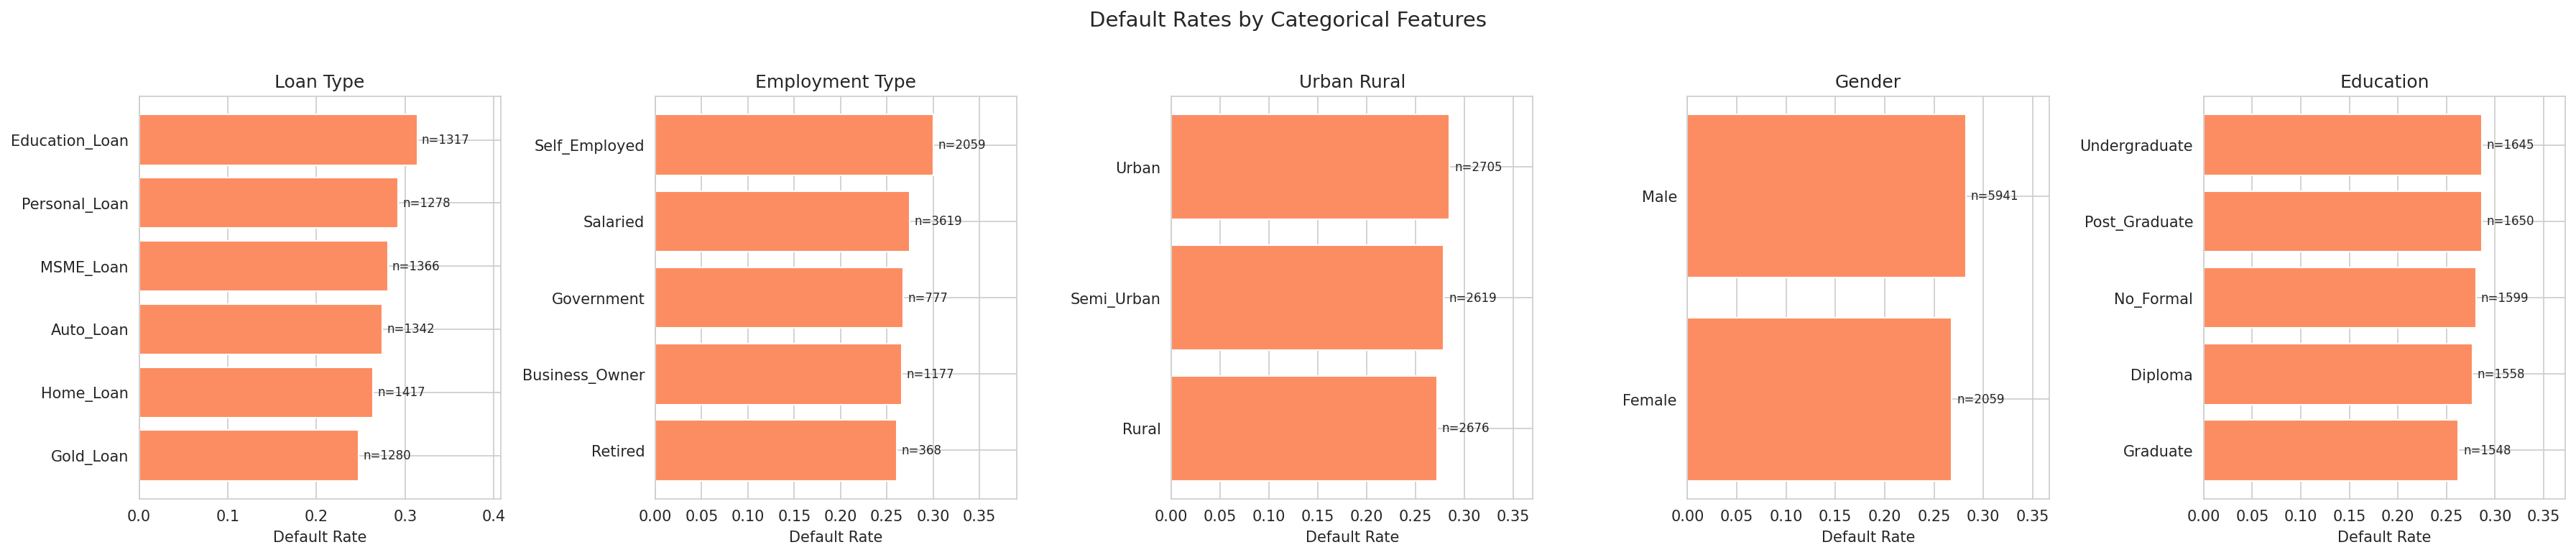

In [17]:
cat_eda_cols = ['loan_type', 'employment_type', 'urban_rural', 'gender', 'education']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for i, col in enumerate(cat_eda_cols):
    ax = axes[i]
    grp = df_train.groupby(col)['default_flag'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'default_rate', 'count']
    grp = grp.sort_values('default_rate', ascending=True)

    bars = ax.barh(grp[col], grp['default_rate'], color=PALETTE[1], edgecolor='white')
    for bar, cnt in zip(bars, grp['count']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'n={cnt}', va='center', fontsize=8)
    ax.set_xlabel('Default Rate')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlim(0, grp['default_rate'].max() * 1.3)

plt.suptitle('Default Rates by Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/3_1_default_by_category.png', bbox_inches='tight')
plt.show()

### 3.2 — Continuous Distributions: Defaulters vs Non-Defaulters (Task 1.2)

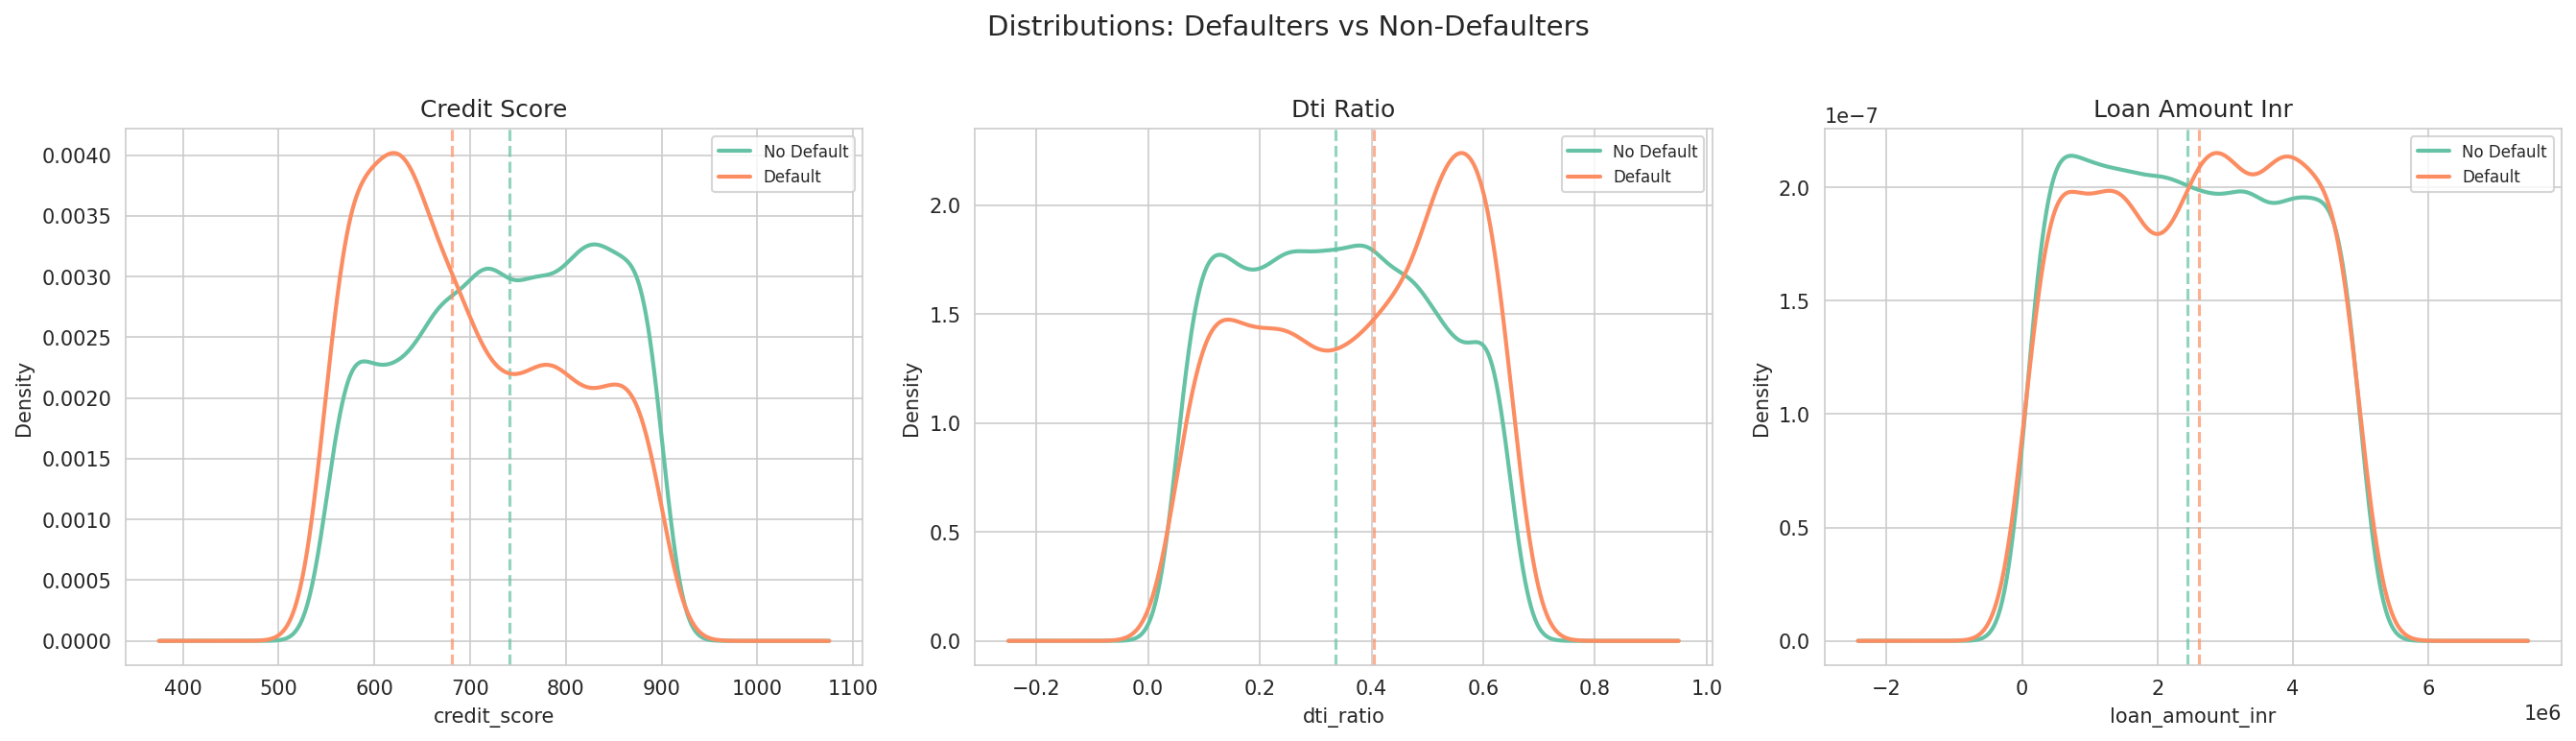

In [18]:
cont_cols = ['credit_score', 'dti_ratio', 'loan_amount_inr']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cont_cols):
    ax = axes[i]
    for flag, label, color in [(0, 'No Default', PALETTE[0]), (1, 'Default', PALETTE[1])]:
        subset = df_train[df_train['default_flag'] == flag][col].dropna()
        subset.plot.kde(ax=ax, label=label, color=color, lw=2)
        med = subset.median()
        ax.axvline(med, color=color, linestyle='--', alpha=0.7)

    # Log scale for loan_amount if very skewed
    if col == 'loan_amount_inr' and df_train[col].skew() > 2:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle('Distributions: Defaulters vs Non-Defaulters', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/3_2_continuous_distributions.png', bbox_inches='tight')
plt.show()

### 3.3 — Credit Score Band Analysis (Task 1.3)

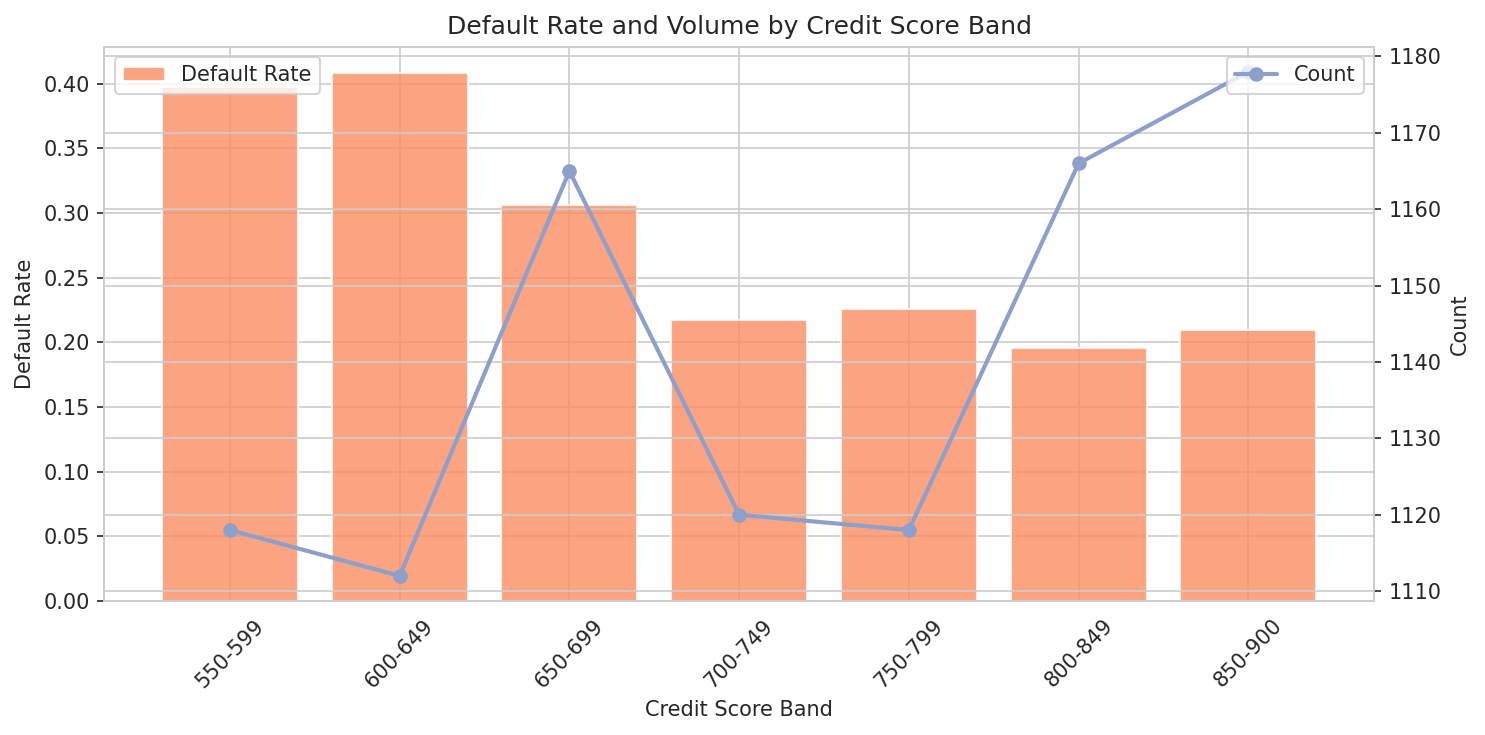

⚠ Non-monotonic: band 600-649 (0.4083) > 550-599 (0.3971)
⚠ Non-monotonic: band 750-799 (0.2254) > 700-749 (0.2170)
⚠ Non-monotonic: band 850-900 (0.2097) > 800-849 (0.1955)


In [19]:
bins = [550, 600, 650, 700, 750, 800, 850, 900]
labels = ['550-599', '600-649', '650-699', '700-749', '750-799', '800-849', '850-900']
df_train['credit_band'] = pd.cut(df_train['credit_score'], bins=bins, labels=labels, right=False)

band_stats = df_train.groupby('credit_band', observed=False)['default_flag'].agg(['mean', 'count']).reset_index()
band_stats.columns = ['band', 'default_rate', 'count']

fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(band_stats))
bars = ax1.bar(x, band_stats['default_rate'], color=PALETTE[1], alpha=0.8, label='Default Rate')
ax1.set_ylabel('Default Rate')
ax1.set_xlabel('Credit Score Band')
ax1.set_xticks(x)
ax1.set_xticklabels(band_stats['band'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, band_stats['count'], color=PALETTE[2], marker='o', lw=2, label='Count')
ax2.set_ylabel('Count')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Default Rate and Volume by Credit Score Band')
plt.tight_layout()
plt.savefig('outputs/plots/3_3_credit_band_analysis.png', bbox_inches='tight')
plt.show()

# Check monotonicity
rates = band_stats['default_rate'].values
for i in range(1, len(rates)):
    if rates[i] > rates[i-1]:
        print(f"⚠ Non-monotonic: band {band_stats['band'].iloc[i]} "
              f"({rates[i]:.4f}) > {band_stats['band'].iloc[i-1]} ({rates[i-1]:.4f})")

df_train.drop(columns='credit_band', inplace=True)

### 3.4 — Temporal Analysis

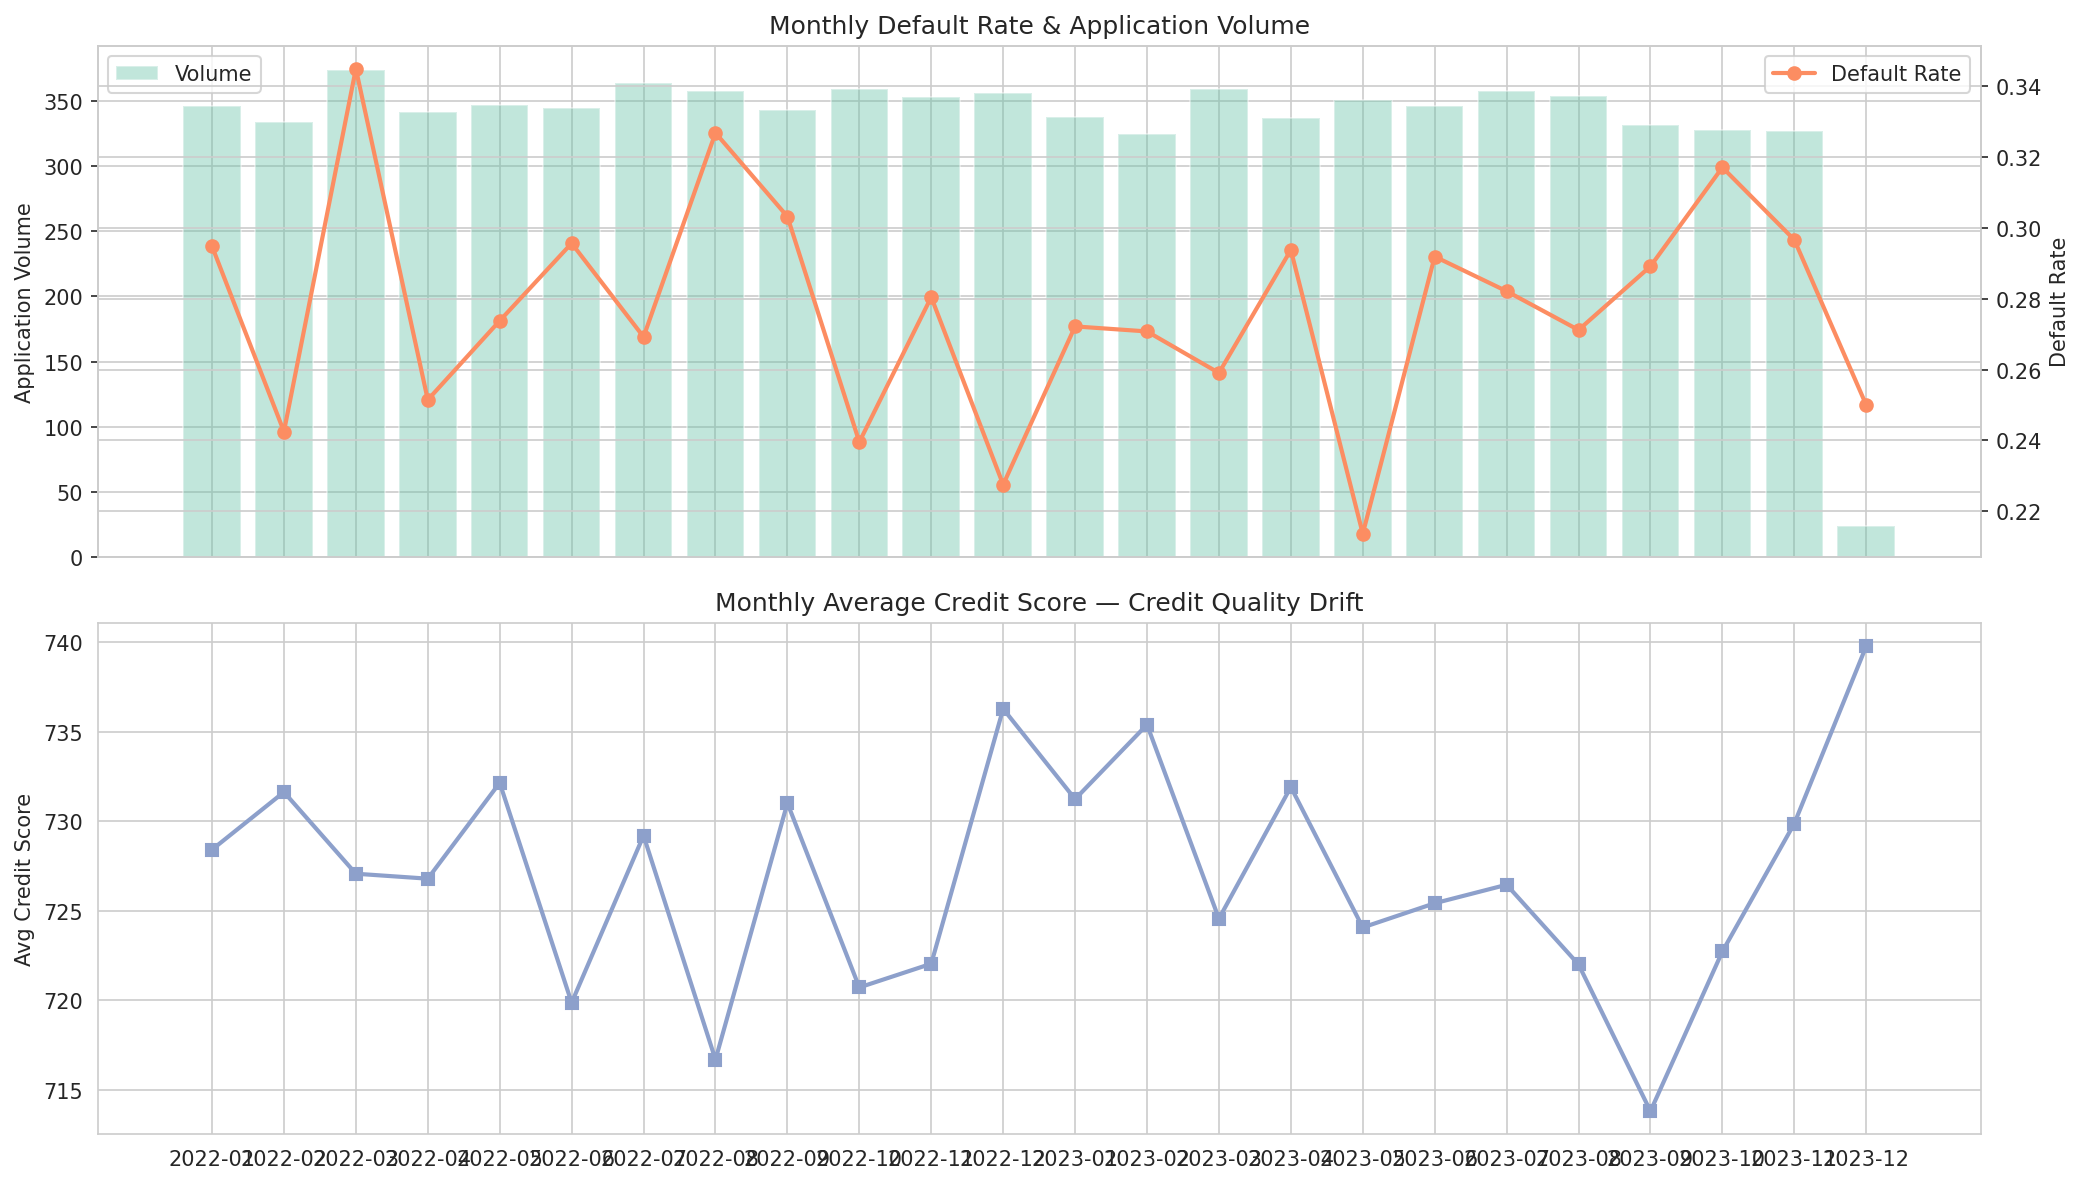

In [20]:
df_train['year_month'] = df_train['application_date'].dt.to_period('M')

monthly = df_train.groupby('year_month').agg(
    default_rate=('default_flag', 'mean'),
    volume=('default_flag', 'count'),
    avg_credit_score=('credit_score', 'mean')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: default rate + volume
ax1 = axes[0]
ax1.bar(monthly['year_month_str'], monthly['volume'], color=PALETTE[0], alpha=0.4, label='Volume')
ax1b = ax1.twinx()
ax1b.plot(monthly['year_month_str'], monthly['default_rate'], color=PALETTE[1], marker='o', lw=2, label='Default Rate')
ax1.set_ylabel('Application Volume')
ax1b.set_ylabel('Default Rate')
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')
ax1.set_title('Monthly Default Rate & Application Volume')

# Panel 2: average credit score
ax2 = axes[1]
ax2.plot(monthly['year_month_str'], monthly['avg_credit_score'], color=PALETTE[2], marker='s', lw=2)
ax2.set_ylabel('Avg Credit Score')
ax2.set_title('Monthly Average Credit Score — Credit Quality Drift')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('outputs/plots/3_4_temporal_analysis.png', bbox_inches='tight')
plt.show()

df_train.drop(columns='year_month', inplace=True)

### 3.5 — Correlation Heatmap

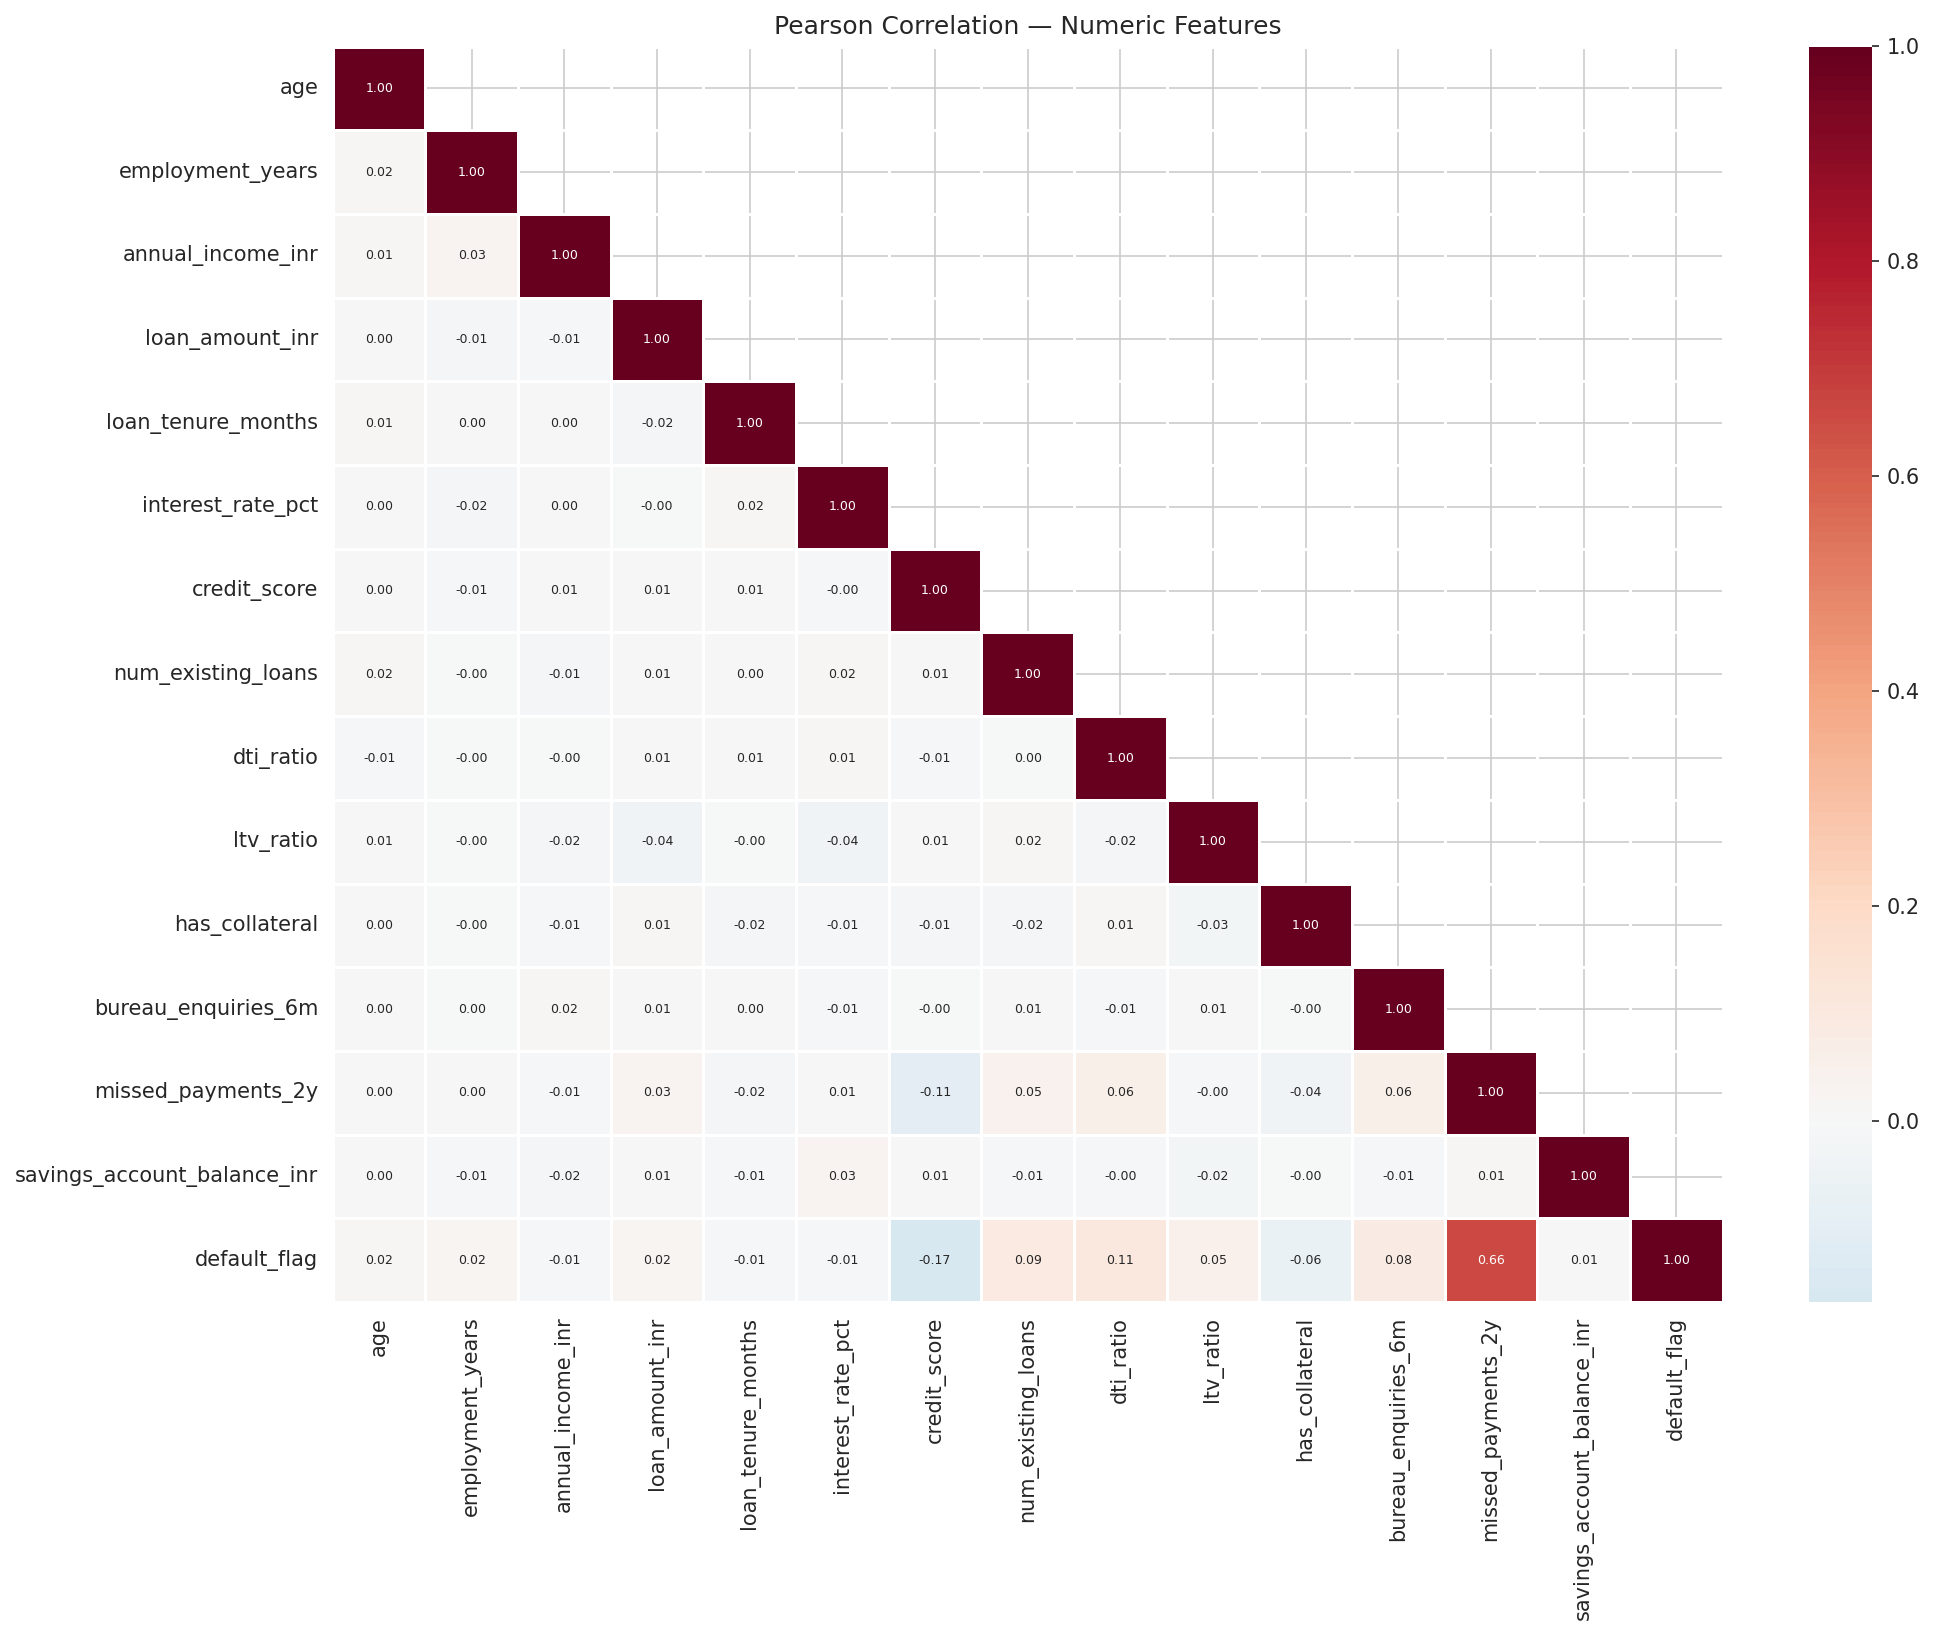

✓ No feature pairs exceed |r| > 0.8.


In [21]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, annot_kws={'size': 6}, linewidths=0.5)
ax.set_title('Pearson Correlation — Numeric Features')
plt.tight_layout()
plt.savefig('outputs/plots/3_5_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
if high_corr:
    print("⚠ Highly correlated pairs (|r| > 0.8):")
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}: {r:.3f}")
else:
    print("✓ No feature pairs exceed |r| > 0.8.")

---
## Section 4: Feature Engineering

In [22]:
# ── 4.1 Outlier Capping (compute on train, apply to both) ──
cap_cols = ['annual_income_inr', 'loan_amount_inr', 'savings_account_balance_inr']
cap_values = {}
for col in cap_cols:
    lo = df_train[col].quantile(0.01)
    hi = df_train[col].quantile(0.99)
    cap_values[col] = (lo, hi)
    print(f"Cap {col}: [{lo:,.0f}, {hi:,.0f}]")

for df in [df_train, df_test]:
    for col, (lo, hi) in cap_values.items():
        df[col] = df[col].clip(lo, hi)

print(f"\nTrain shape after capping: {df_train.shape}")
print(f"Test shape after capping:  {df_test.shape}")

Cap annual_income_inr: [279,065, 2,975,038]
Cap loan_amount_inr: [91,599, 4,944,933]
Cap savings_account_balance_inr: [4,620, 494,884]

Train shape after capping: (8000, 24)
Test shape after capping:  (2500, 23)


In [23]:
# ── 4.2 LTV Ratio Handling ──
for df in [df_train, df_test]:
    df['ltv_is_missing'] = df['ltv_ratio'].isnull().astype(int)
    df['ltv_ratio'] = df['ltv_ratio'].fillna(-1)

print("LTV handling done. ltv_is_missing value counts (train):")
print(df_train['ltv_is_missing'].value_counts())

LTV handling done. ltv_is_missing value counts (train):
ltv_is_missing
1    6583
0    1417
Name: count, dtype: int64


In [24]:
# ── 4.3 Required Features ──
for df in [df_train, df_test]:
    df['loan_to_income_ratio'] = df['loan_amount_inr'] / (df['annual_income_inr'] + 1)
    df['dti_credit_risk'] = df['dti_ratio'] / (df['credit_score'] / 700)
    df['income_per_year_employed'] = df['annual_income_inr'] / (df['employment_years'] + 1)

print("Required features created: loan_to_income_ratio, dti_credit_risk, income_per_year_employed")

Required features created: loan_to_income_ratio, dti_credit_risk, income_per_year_employed


In [25]:
# ── 4.4 Temporal Features ──
earliest_date = df_train['application_date'].min()
print(f"Earliest application date in train: {earliest_date}")

for df in [df_train, df_test]:
    df['app_month'] = df['application_date'].dt.month
    df['app_quarter'] = df['application_date'].dt.quarter
    df['app_day_of_week'] = df['application_date'].dt.dayofweek
    df['days_since_earliest'] = (df['application_date'] - earliest_date).dt.days

# Drop application_date
for df in [df_train, df_test]:
    df.drop(columns='application_date', inplace=True)

print("Temporal features created. application_date dropped.")
print(f"Train shape: {df_train.shape}")

Earliest application date in train: 2022-01-01 00:00:00
Temporal features created. application_date dropped.
Train shape: (8000, 31)


In [26]:
# ── 4.5 Advanced Domain Features ──

def create_advanced_features(df, interest_rate_medians=None, fit=False):
    """Create all advanced domain features.
    If fit=True, compute reference values from this df and return them.
    Otherwise use provided reference values."""

    # --- Financial stress ---
    # EMI calculation: P * r * (1+r)^n / ((1+r)^n - 1)
    P = df['loan_amount_inr']
    r = df['interest_rate_pct'] / 100 / 12  # monthly rate
    n = df['loan_tenure_months']
    # Handle edge case where r is 0
    r_safe = r.replace(0, 1e-9)
    compound = (1 + r_safe) ** n
    emi = P * r_safe * compound / (compound - 1)
    emi = emi.fillna(0)

    monthly_income = df['annual_income_inr'] / 12
    df['emi_to_income_ratio'] = emi / (monthly_income + 1)
    df['total_debt_exposure'] = df['loan_amount_inr'] * (1 + df['dti_ratio'])
    df['savings_to_loan_ratio'] = df['savings_account_balance_inr'] / (df['loan_amount_inr'] + 1)
    df['savings_to_emi_ratio'] = df['savings_account_balance_inr'] / (emi + 1)

    # --- Behavioral risk ---
    df['missed_payment_rate'] = df['missed_payments_2y'] / (df['num_existing_loans'] + 1)
    df['enquiry_intensity'] = df['bureau_enquiries_6m'] / (df['num_existing_loans'] + 1)
    df['credit_utilization_proxy'] = df['num_existing_loans'] * df['dti_ratio']

    # --- Credit profile ---
    df['credit_score_squared'] = df['credit_score'] ** 2
    df['credit_score_x_dti'] = df['credit_score'] * df['dti_ratio']
    df['low_credit_flag'] = (df['credit_score'] < 650).astype(int)
    df['high_dti_flag'] = (df['dti_ratio'] > 0.45).astype(int)
    df['high_risk_combo'] = ((df['low_credit_flag'] == 1) & (df['high_dti_flag'] == 1)).astype(int)

    # --- Loan characteristics ---
    # Interest spread: deviation from loan_type median (computed on train)
    if fit:
        interest_rate_medians = df.groupby('loan_type')['interest_rate_pct'].median().to_dict()
    df['interest_spread'] = df.apply(
        lambda row: row['interest_rate_pct'] - interest_rate_medians.get(row['loan_type'], 0), axis=1)

    df['tenure_years'] = df['loan_tenure_months'] / 12
    df['total_repayment'] = df['loan_amount_inr'] * (1 + df['interest_rate_pct'] / 100 * df['tenure_years'])

    if fit:
        return interest_rate_medians
    return None

# Fit on train, apply to both
ir_medians = create_advanced_features(df_train, fit=True)
create_advanced_features(df_test, interest_rate_medians=ir_medians, fit=False)

print("Advanced domain features created.")
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Advanced domain features created.
Train shape: (8000, 46)
Test shape:  (2500, 45)


In [27]:
# ── 4.6 Categorical Encoding ──

# --- Target encoding for state, loan_purpose ---
target_encode_cols = ['state', 'loan_purpose']
SMOOTHING = 10  # regularization weight

# Store global means for test encoding
global_default_mean = df_train['default_flag'].mean()
target_enc_maps = {}

skf_te = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for col in target_encode_cols:
    # Compute full-train means (for test)
    cat_means = df_train.groupby(col)['default_flag'].agg(['mean', 'count'])
    cat_means['smoothed'] = (cat_means['count'] * cat_means['mean'] + SMOOTHING * global_default_mean) / (cat_means['count'] + SMOOTHING)
    target_enc_maps[col] = cat_means['smoothed'].to_dict()

    # Fold-based encoding for train
    df_train[col + '_te'] = np.nan
    for tr_idx, val_idx in skf_te.split(df_train, df_train['default_flag']):
        fold_means = df_train.iloc[tr_idx].groupby(col)['default_flag'].agg(['mean', 'count'])
        fold_means['smoothed'] = (fold_means['count'] * fold_means['mean'] + SMOOTHING * global_default_mean) / (fold_means['count'] + SMOOTHING)
        fold_map = fold_means['smoothed'].to_dict()
        df_train.loc[df_train.index[val_idx], col + '_te'] = df_train.iloc[val_idx][col].map(fold_map)

    # Fill any remaining NaN with global mean
    df_train[col + '_te'] = df_train[col + '_te'].fillna(global_default_mean)

    # Test: use full train means
    df_test[col + '_te'] = df_test[col].map(target_enc_maps[col]).fillna(global_default_mean)

print("Target encoding done for:", target_encode_cols)

# --- One-hot encoding for low-cardinality categoricals ---
ohe_cols = ['gender', 'education', 'urban_rural', 'employment_type', 'loan_type']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(df_train[ohe_cols])

ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

train_ohe = pd.DataFrame(ohe.transform(df_train[ohe_cols]), columns=ohe_feature_names, index=df_train.index)
test_ohe  = pd.DataFrame(ohe.transform(df_test[ohe_cols]),  columns=ohe_feature_names, index=df_test.index)

df_train = pd.concat([df_train, train_ohe], axis=1)
df_test  = pd.concat([df_test,  test_ohe],  axis=1)

print(f"One-hot features added: {len(ohe_feature_names)}")

# --- Drop original categorical columns, loan_id ---
drop_cols = ['loan_id'] + target_encode_cols + ohe_cols
# Keep only columns that exist
drop_cols = [c for c in drop_cols if c in df_train.columns]

# Store loan_ids from test before dropping (needed for predictions)
test_loan_ids = df_test['loan_id'].values if 'loan_id' in df_test.columns else None

df_train.drop(columns=drop_cols, inplace=True)
df_test.drop(columns=[c for c in drop_cols if c in df_test.columns], inplace=True)

print(f"\nDropped columns: {drop_cols}")
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Target encoding done for: ['state', 'loan_purpose']
One-hot features added: 16

Dropped columns: ['loan_id', 'state', 'loan_purpose', 'gender', 'education', 'urban_rural', 'employment_type', 'loan_type']
Train shape: (8000, 56)
Test shape:  (2500, 55)


In [28]:
# ── 4.7 Feature Scaling ──
y_train = df_train.pop('default_flag')
y_test  = df_test.pop('default_flag') if TEST_HAS_TARGET else None

feature_cols = df_train.columns.tolist()

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(df_train), columns=feature_cols, index=df_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(df_test),      columns=feature_cols, index=df_test.index)

print(f"Scaling done. Scaler fitted on {len(feature_cols)} features.")
print(f"X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
if y_test is not None:
    print(f"X_test:  {X_test_scaled.shape}, y_test:  {y_test.shape}")
else:
    print(f"X_test:  {X_test_scaled.shape}, y_test:  N/A")

Scaling done. Scaler fitted on 55 features.
X_train: (8000, 55), y_train: (8000,)
X_test:  (2500, 55), y_test:  N/A


In [29]:
# ── 4.8 Final Feature Count ──
print(f"\n{'='*60}")
print(f"  Final Feature Count: {len(feature_cols)}")
print(f"{'='*60}")
print("\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:3d}. {col}")


  Final Feature Count: 55

Feature list:
    1. age
    2. employment_years
    3. annual_income_inr
    4. loan_amount_inr
    5. loan_tenure_months
    6. interest_rate_pct
    7. credit_score
    8. num_existing_loans
    9. dti_ratio
   10. ltv_ratio
   11. has_collateral
   12. bureau_enquiries_6m
   13. missed_payments_2y
   14. savings_account_balance_inr
   15. ltv_is_missing
   16. loan_to_income_ratio
   17. dti_credit_risk
   18. income_per_year_employed
   19. app_month
   20. app_quarter
   21. app_day_of_week
   22. days_since_earliest
   23. emi_to_income_ratio
   24. total_debt_exposure
   25. savings_to_loan_ratio
   26. savings_to_emi_ratio
   27. missed_payment_rate
   28. enquiry_intensity
   29. credit_utilization_proxy
   30. credit_score_squared
   31. credit_score_x_dti
   32. low_credit_flag
   33. high_dti_flag
   34. high_risk_combo
   35. interest_spread
   36. tenure_years
   37. total_repayment
   38. state_te
   39. loan_purpose_te
   40. gender_Male
   

---
## Section 5: Post-Engineering Correlation Analysis

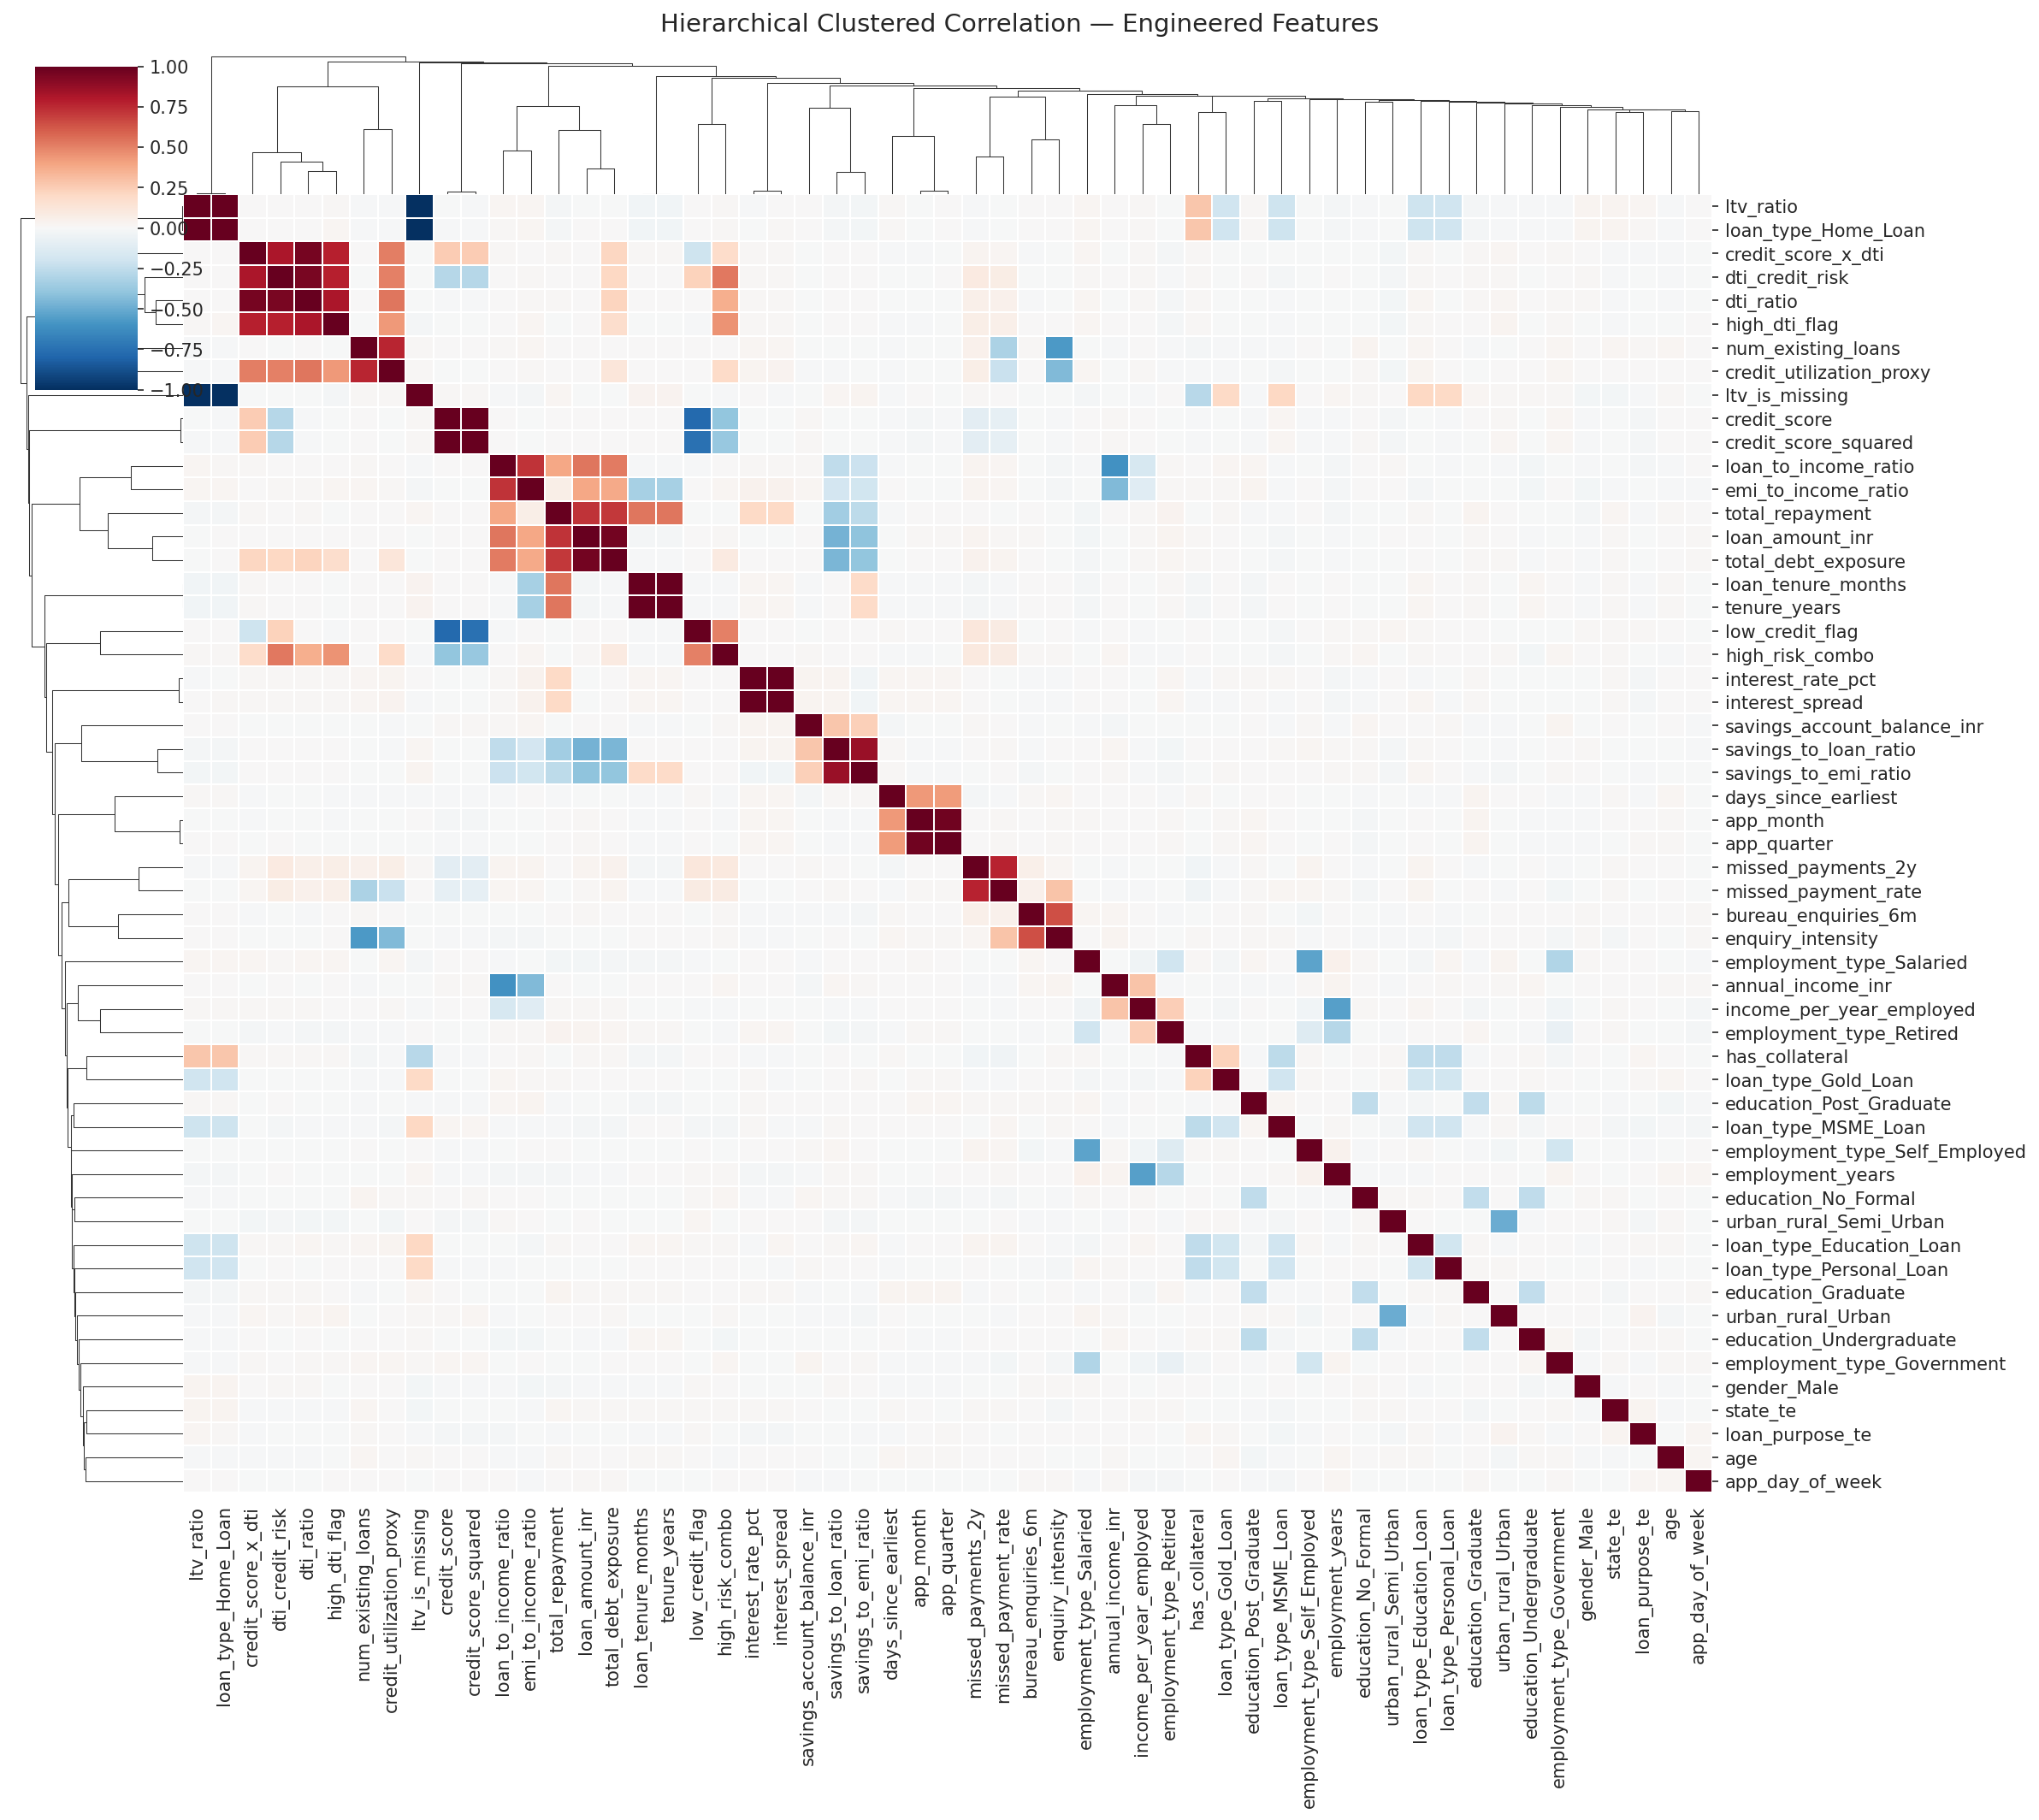

In [30]:
# ── Clustermap of engineered features ──
corr_eng = X_train_scaled.corr()

g = sns.clustermap(corr_eng, cmap='RdBu_r', center=0, figsize=(16, 14),
                   annot=False, linewidths=0.1, dendrogram_ratio=0.1)
g.fig.suptitle('Hierarchical Clustered Correlation — Engineered Features', y=1.01, fontsize=14)
g.savefig('outputs/plots/5_clustermap.png', bbox_inches='tight')
plt.show()

In [31]:
# ── Highly correlated pairs (|r| > 0.85) ──
print("── Feature pairs with |r| > 0.85 ──")
pairs_85 = []
for i in range(len(corr_eng)):
    for j in range(i+1, len(corr_eng)):
        r = corr_eng.iloc[i, j]
        if abs(r) > 0.85:
            pairs_85.append((corr_eng.index[i], corr_eng.columns[j], r))

if pairs_85:
    for a, b, r in sorted(pairs_85, key=lambda x: -abs(x[2])):
        print(f"  {a} ↔ {b}: {r:.3f}")
else:
    print("  None found.")

── Feature pairs with |r| > 0.85 ──
  loan_tenure_months ↔ tenure_years: 1.000
  ltv_is_missing ↔ loan_type_Home_Loan: -1.000
  interest_rate_pct ↔ interest_spread: 0.999
  credit_score ↔ credit_score_squared: 0.998
  ltv_ratio ↔ ltv_is_missing: -0.995
  ltv_ratio ↔ loan_type_Home_Loan: 0.995
  app_month ↔ app_quarter: 0.970
  loan_amount_inr ↔ total_debt_exposure: 0.969
  dti_ratio ↔ credit_score_x_dti: 0.954
  dti_ratio ↔ dti_credit_risk: 0.952
  savings_to_loan_ratio ↔ savings_to_emi_ratio: 0.866


In [32]:
# ── Point-biserial correlation with target ──
pb_corr = X_train_scaled.apply(lambda col: col.corr(y_train)).sort_values(ascending=False)

print("\n── Top 20 features by correlation with default_flag ──")
print(pb_corr.head(20).to_string())
print("\n── Bottom 20 features (most negative correlation) ──")
print(pb_corr.tail(20).to_string())


── Top 20 features by correlation with default_flag ──
missed_payments_2y               0.657394
missed_payment_rate              0.488551
low_credit_flag                  0.172235
dti_credit_risk                  0.149086
high_risk_combo                  0.147239
credit_utilization_proxy         0.121514
high_dti_flag                    0.118367
dti_ratio                        0.106708
num_existing_loans               0.087884
bureau_enquiries_6m              0.079726
credit_score_x_dti               0.056569
total_debt_exposure              0.045083
loan_type_Education_Loan         0.034752
employment_type_Self_Employed    0.028428
loan_amount_inr                  0.020585
state_te                         0.020235
employment_years                 0.019243
loan_to_income_ratio             0.015750
age                              0.015650
ltv_is_missing                   0.015072

── Bottom 20 features (most negative correlation) ──
app_quarter                  -0.002357
days_since_

---
## Section 6: Model Building & Cross-Validation (Task 3)

In [33]:
# ── 6.1 Setup ──
X = X_train_scaled.values
y = y_train.values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for results
results = {}
oof_preds = {}

# Class balance for scale_pos_weight
n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
spw = n_neg / n_pos
print(f"Class balance — 0: {n_neg}, 1: {n_pos}, scale_pos_weight: {spw:.2f}")

Class balance — 0: 5772, 1: 2228, scale_pos_weight: 2.59


### 6.2 — Model 1: Logistic Regression

In [34]:
lr_aucs, lr_praucs, lr_f1s = [], [], []
oof_lr = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    lr = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000,
                            class_weight='balanced', random_state=SEED)
    lr.fit(X_tr, y_tr)
    proba = lr.predict_proba(X_val)[:, 1]
    oof_lr[val_idx] = proba

    lr_aucs.append(roc_auc_score(y_val, proba))
    lr_praucs.append(average_precision_score(y_val, proba))
    lr_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))

    print(f"  Fold {fold+1}: ROC-AUC={lr_aucs[-1]:.4f}  PR-AUC={lr_praucs[-1]:.4f}  F1={lr_f1s[-1]:.4f}")

results['Logistic Regression'] = {
    'roc_auc': (np.mean(lr_aucs), np.std(lr_aucs)),
    'pr_auc':  (np.mean(lr_praucs), np.std(lr_praucs)),
    'f1':      (np.mean(lr_f1s), np.std(lr_f1s)),
}
oof_preds['Logistic Regression'] = oof_lr
print(f"\n  Mean: ROC-AUC={np.mean(lr_aucs):.4f}±{np.std(lr_aucs):.4f}")

  Fold 1: ROC-AUC=0.8819  PR-AUC=0.7986  F1=0.7000
  Fold 2: ROC-AUC=0.9180  PR-AUC=0.8540  F1=0.7469
  Fold 3: ROC-AUC=0.8956  PR-AUC=0.8305  F1=0.7275
  Fold 4: ROC-AUC=0.9011  PR-AUC=0.8414  F1=0.7241
  Fold 5: ROC-AUC=0.9077  PR-AUC=0.8301  F1=0.7292

  Mean: ROC-AUC=0.9008±0.0121


### 6.3 — Model 2: XGBoost

In [35]:
xgb_aucs, xgb_praucs, xgb_f1s = [], [], []
xgb_best_iters = []
oof_xgb = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model_xgb = xgb.XGBClassifier(
        n_estimators=1000, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw,
        eval_metric='auc', early_stopping_rounds=50,
        random_state=SEED, use_label_encoder=False, verbosity=0
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    proba = model_xgb.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = proba
    xgb_best_iters.append(model_xgb.best_iteration)

    xgb_aucs.append(roc_auc_score(y_val, proba))
    xgb_praucs.append(average_precision_score(y_val, proba))
    xgb_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))

    print(f"  Fold {fold+1}: ROC-AUC={xgb_aucs[-1]:.4f}  PR-AUC={xgb_praucs[-1]:.4f}  "
          f"F1={xgb_f1s[-1]:.4f}  best_iter={xgb_best_iters[-1]}")

results['XGBoost'] = {
    'roc_auc': (np.mean(xgb_aucs), np.std(xgb_aucs)),
    'pr_auc':  (np.mean(xgb_praucs), np.std(xgb_praucs)),
    'f1':      (np.mean(xgb_f1s), np.std(xgb_f1s)),
}
oof_preds['XGBoost'] = oof_xgb
avg_best_iter_xgb = int(np.mean(xgb_best_iters))
print(f"\n  Mean: ROC-AUC={np.mean(xgb_aucs):.4f}±{np.std(xgb_aucs):.4f}, avg best_iter={avg_best_iter_xgb}")

  Fold 1: ROC-AUC=0.8768  PR-AUC=0.8008  F1=0.7078  best_iter=10
  Fold 2: ROC-AUC=0.9131  PR-AUC=0.8474  F1=0.7479  best_iter=56
  Fold 3: ROC-AUC=0.8963  PR-AUC=0.8238  F1=0.7213  best_iter=23
  Fold 4: ROC-AUC=0.9004  PR-AUC=0.8344  F1=0.7275  best_iter=70
  Fold 5: ROC-AUC=0.9061  PR-AUC=0.8192  F1=0.7403  best_iter=87

  Mean: ROC-AUC=0.8985±0.0122, avg best_iter=49


### 6.4 — Model 3: LightGBM

In [36]:
lgb_aucs, lgb_praucs, lgb_f1s = [], [], []
lgb_best_iters = []
oof_lgb = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model_lgb = lgb.LGBMClassifier(
        n_estimators=1000, max_depth=7, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
        is_unbalance=True, metric='auc',
        random_state=SEED, verbosity=-1
    )
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

    proba = model_lgb.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = proba
    lgb_best_iters.append(model_lgb.best_iteration_)

    lgb_aucs.append(roc_auc_score(y_val, proba))
    lgb_praucs.append(average_precision_score(y_val, proba))
    lgb_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))

    print(f"  Fold {fold+1}: ROC-AUC={lgb_aucs[-1]:.4f}  PR-AUC={lgb_praucs[-1]:.4f}  "
          f"F1={lgb_f1s[-1]:.4f}  best_iter={lgb_best_iters[-1]}")

results['LightGBM'] = {
    'roc_auc': (np.mean(lgb_aucs), np.std(lgb_aucs)),
    'pr_auc':  (np.mean(lgb_praucs), np.std(lgb_praucs)),
    'f1':      (np.mean(lgb_f1s), np.std(lgb_f1s)),
}
oof_preds['LightGBM'] = oof_lgb
avg_best_iter_lgb = int(np.mean(lgb_best_iters))
print(f"\n  Mean: ROC-AUC={np.mean(lgb_aucs):.4f}±{np.std(lgb_aucs):.4f}, avg best_iter={avg_best_iter_lgb}")

  Fold 1: ROC-AUC=0.8742  PR-AUC=0.7966  F1=0.7138  best_iter=28
  Fold 2: ROC-AUC=0.9123  PR-AUC=0.8466  F1=0.7411  best_iter=74
  Fold 3: ROC-AUC=0.8919  PR-AUC=0.8244  F1=0.7211  best_iter=39
  Fold 4: ROC-AUC=0.8966  PR-AUC=0.8277  F1=0.7241  best_iter=72
  Fold 5: ROC-AUC=0.9048  PR-AUC=0.8216  F1=0.7450  best_iter=55

  Mean: ROC-AUC=0.8959±0.0129, avg best_iter=53


### 6.5 — Results Comparison Table

Model                  ROC-AUC (CV)       PR-AUC (CV)        F1 (CV)           
----------------------------------------------------------------------------
Logistic Regression    0.9008 ± 0.0121    0.8309 ± 0.0184    0.7255 ± 0.0150   
XGBoost                0.8985 ± 0.0122    0.8251 ± 0.0156    0.7289 ± 0.0141   
LightGBM               0.8959 ± 0.0129    0.8234 ± 0.0160    0.7290 ± 0.0120   


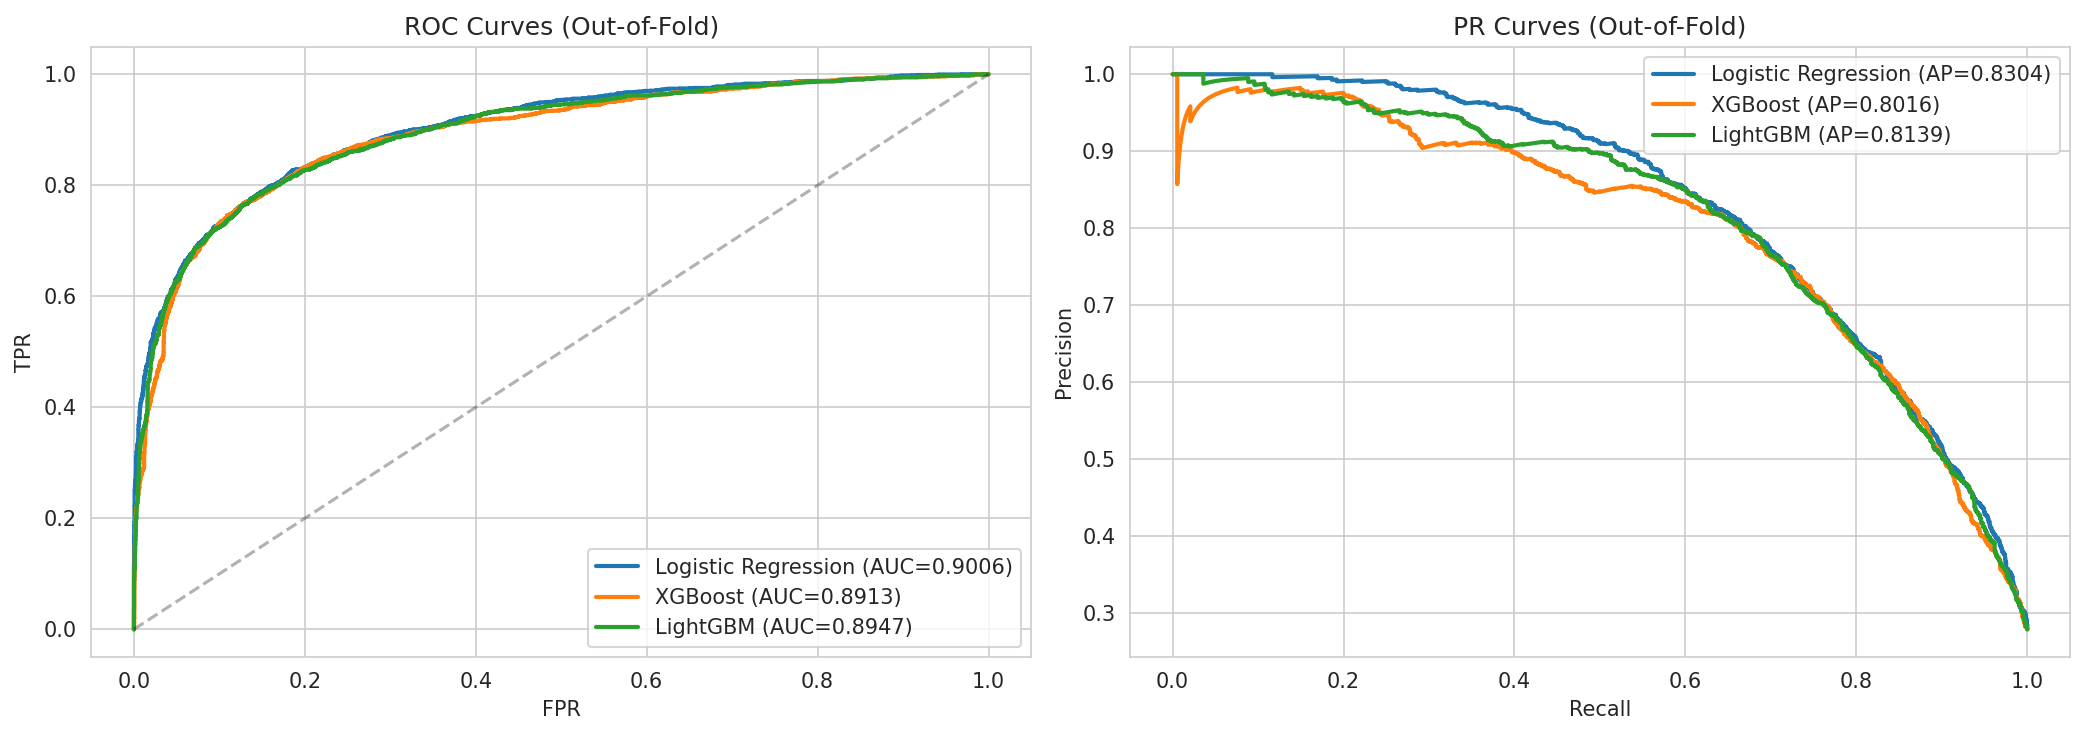

In [37]:
# Print comparison table
print(f"{'Model':<22} {'ROC-AUC (CV)':<18} {'PR-AUC (CV)':<18} {'F1 (CV)':<18}")
print("-" * 76)
for name, res in results.items():
    roc_str = f"{res['roc_auc'][0]:.4f} ± {res['roc_auc'][1]:.4f}"
    pr_str  = f"{res['pr_auc'][0]:.4f} ± {res['pr_auc'][1]:.4f}"
    f1_str  = f"{res['f1'][0]:.4f} ± {res['f1'][1]:.4f}"
    print(f"{name:<22} {roc_str:<18} {pr_str:<18} {f1_str:<18}")

# Plot ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, oof in oof_preds.items():
    # ROC
    fpr, tpr, _ = roc_curve(y, oof)
    auc_val = roc_auc_score(y, oof)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.4f})')

    # PR
    prec, rec, _ = precision_recall_curve(y, oof)
    ap = average_precision_score(y, oof)
    axes[1].plot(rec, prec, lw=2, label=f'{name} (AP={ap:.4f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves (Out-of-Fold)'); axes[0].legend()

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves (Out-of-Fold)'); axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/plots/6_5_roc_pr_curves.png', bbox_inches='tight')
plt.show()

### 6.6 — Best Model Selection

In [38]:
# Select best model by ROC-AUC, then PR-AUC as tiebreaker
best_name = max(results, key=lambda k: (results[k]['roc_auc'][0], results[k]['pr_auc'][0]))
print(f"✅ Best model: {best_name}")
print(f"   ROC-AUC: {results[best_name]['roc_auc'][0]:.4f} ± {results[best_name]['roc_auc'][1]:.4f}")
print(f"   PR-AUC:  {results[best_name]['pr_auc'][0]:.4f} ± {results[best_name]['pr_auc'][1]:.4f}")
print(f"   F1:      {results[best_name]['f1'][0]:.4f} ± {results[best_name]['f1'][1]:.4f}")

best_oof = oof_preds[best_name]

✅ Best model: Logistic Regression
   ROC-AUC: 0.9008 ± 0.0121
   PR-AUC:  0.8309 ± 0.0184
   F1:      0.7255 ± 0.0150


**Model Selection Justification:**

The best model is selected based on the highest cross-validated ROC-AUC, with PR-AUC as the tiebreaker (PR-AUC is more informative under class imbalance since it focuses on the minority class). We also consider fold stability (low std across folds) and practical interpretability. Tree-based models (XGBoost/LightGBM) typically outperform logistic regression on tabular credit risk data due to their ability to capture non-linear interactions, while logistic regression serves as a strong interpretable baseline.

### 6.7 — KS Statistic (Task 3.3)

KS Statistic: 64.13
Max separation at threshold: 0.431
Interpretation: Excellent


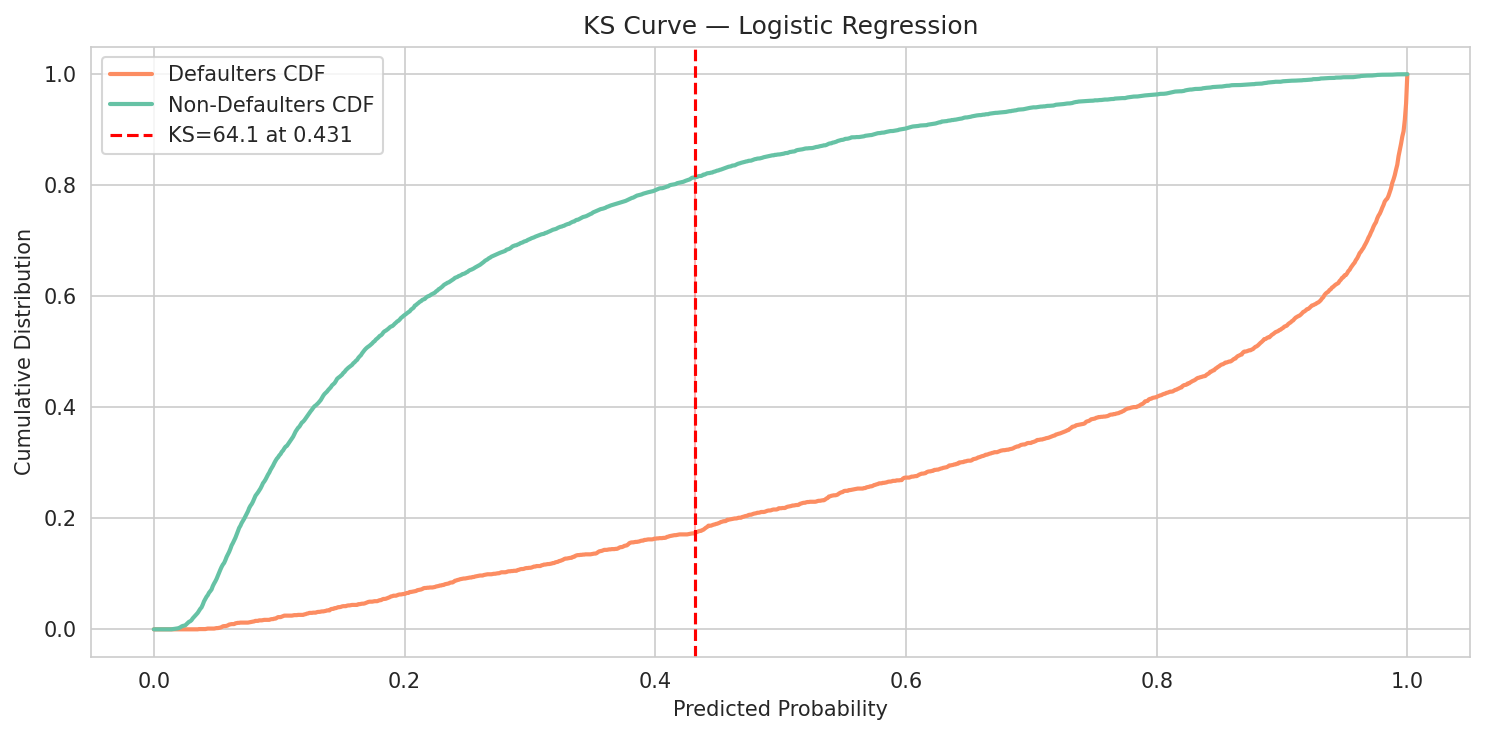

In [39]:
# KS Statistic
default_probs = best_oof[y == 1]
non_default_probs = best_oof[y == 0]

# CDFs
thresholds = np.linspace(0, 1, 1000)
cdf_default = np.array([np.mean(default_probs <= t) for t in thresholds])
cdf_non_default = np.array([np.mean(non_default_probs <= t) for t in thresholds])

ks_values = np.abs(cdf_default - cdf_non_default)
ks_stat = ks_values.max()
ks_threshold = thresholds[np.argmax(ks_values)]

print(f"KS Statistic: {ks_stat*100:.2f}")
print(f"Max separation at threshold: {ks_threshold:.3f}")
print(f"Interpretation: {'Excellent' if ks_stat*100 > 50 else 'Good' if ks_stat*100 > 40 else 'Moderate'}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, cdf_default, label='Defaulters CDF', color=PALETTE[1], lw=2)
ax.plot(thresholds, cdf_non_default, label='Non-Defaulters CDF', color=PALETTE[0], lw=2)
ax.axvline(ks_threshold, color='red', linestyle='--', lw=1.5, label=f'KS={ks_stat*100:.1f} at {ks_threshold:.3f}')
ax.fill_betweenx([cdf_non_default[np.argmax(ks_values)], cdf_default[np.argmax(ks_values)]],
                 ks_threshold, ks_threshold, color='red', alpha=0.3)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Cumulative Distribution')
ax.set_title(f'KS Curve — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/6_7_ks_curve.png', bbox_inches='tight')
plt.show()

### 6.8 — Threshold Optimization (Task 3.4)

✅ Optimal threshold (max F1): 0.61
   Precision: 0.7502
   Recall:    0.7226
   F1:        0.7362

📌 Conservative threshold (precision ≥ 70%): 0.61
   Precision: 0.7502
   Recall:    0.7226
   F1:        0.7362


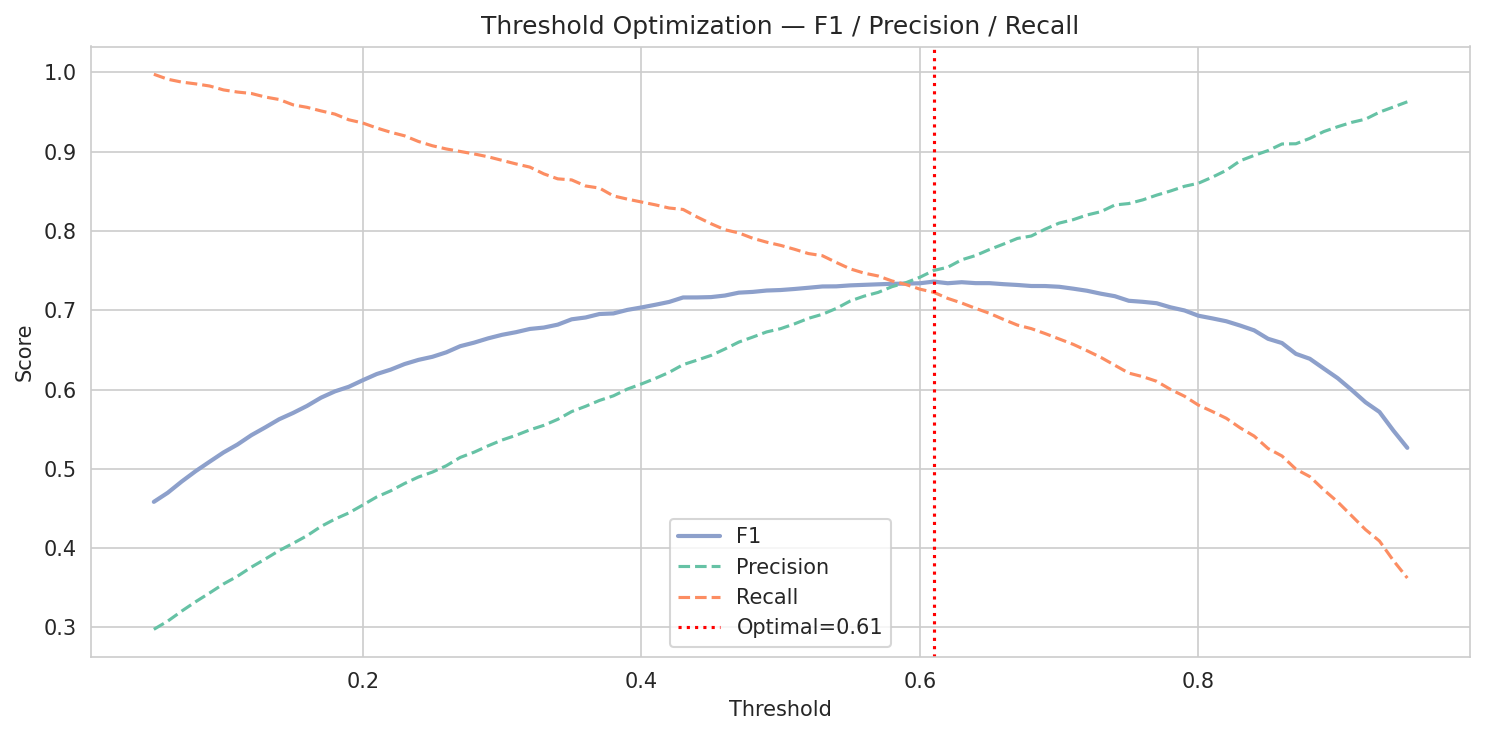

In [40]:
# F1 at various thresholds
thresholds_opt = np.arange(0.05, 0.96, 0.01)
f1_scores_thr = []
precisions_thr = []
recalls_thr = []

for t in thresholds_opt:
    preds = (best_oof >= t).astype(int)
    tp = ((preds == 1) & (y == 1)).sum()
    fp = ((preds == 1) & (y == 0)).sum()
    fn = ((preds == 0) & (y == 1)).sum()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    f1_scores_thr.append(f1)
    precisions_thr.append(prec)
    recalls_thr.append(rec)

f1_scores_thr = np.array(f1_scores_thr)
precisions_thr = np.array(precisions_thr)
recalls_thr = np.array(recalls_thr)

# Optimal threshold (max F1)
best_idx = np.argmax(f1_scores_thr)
optimal_threshold = thresholds_opt[best_idx]
print(f"✅ Optimal threshold (max F1): {optimal_threshold:.2f}")
print(f"   Precision: {precisions_thr[best_idx]:.4f}")
print(f"   Recall:    {recalls_thr[best_idx]:.4f}")
print(f"   F1:        {f1_scores_thr[best_idx]:.4f}")

# Conservative threshold (precision >= 70%)
conservative_mask = precisions_thr >= 0.70
if conservative_mask.any():
    # Among those with precision >= 70%, pick the one with highest F1
    cons_idx = np.where(conservative_mask)[0]
    best_cons = cons_idx[np.argmax(f1_scores_thr[cons_idx])]
    conservative_threshold = thresholds_opt[best_cons]
    print(f"\n📌 Conservative threshold (precision ≥ 70%): {conservative_threshold:.2f}")
    print(f"   Precision: {precisions_thr[best_cons]:.4f}")
    print(f"   Recall:    {recalls_thr[best_cons]:.4f}")
    print(f"   F1:        {f1_scores_thr[best_cons]:.4f}")
else:
    conservative_threshold = optimal_threshold
    print("\n   No threshold achieves precision ≥ 70%.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_opt, f1_scores_thr, label='F1', lw=2, color=PALETTE[2])
ax.plot(thresholds_opt, precisions_thr, label='Precision', lw=1.5, linestyle='--', color=PALETTE[0])
ax.plot(thresholds_opt, recalls_thr, label='Recall', lw=1.5, linestyle='--', color=PALETTE[1])
ax.axvline(optimal_threshold, color='red', linestyle=':', label=f'Optimal={optimal_threshold:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — F1 / Precision / Recall')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/6_8_threshold_optimization.png', bbox_inches='tight')
plt.show()

### 6.9 — Final Test Set Evaluation

In [41]:
if not TEST_HAS_TARGET:
    print("⚠ Test set does not have default_flag. Skipping test evaluation.")
else:
    # Retrain best model on full training data
    X_full = X_train_scaled.values
    y_full = y_train.values
    X_test_arr = X_test_scaled.values

    if best_name == 'Logistic Regression':
        final_model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                                         max_iter=1000, class_weight='balanced', random_state=SEED)
        final_model.fit(X_full, y_full)
    elif best_name == 'XGBoost':
        final_model = xgb.XGBClassifier(
            n_estimators=avg_best_iter_xgb, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw,
            eval_metric='auc', random_state=SEED, use_label_encoder=False, verbosity=0
        )
        final_model.fit(X_full, y_full)
    else:  # LightGBM
        final_model = lgb.LGBMClassifier(
            n_estimators=avg_best_iter_lgb, max_depth=7, learning_rate=0.05,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
            is_unbalance=True, metric='auc', random_state=SEED, verbosity=-1
        )
        final_model.fit(X_full, y_full)

    # Predict on test
    test_proba = final_model.predict_proba(X_test_arr)[:, 1]
    test_preds = (test_proba >= optimal_threshold).astype(int)

    test_roc_auc = roc_auc_score(y_test, test_proba)
    test_pr_auc  = average_precision_score(y_test, test_proba)
    test_f1      = f1_score(y_test, test_preds)

    print(f"\n{'='*60}")
    print(f"  TEST SET EVALUATION — {best_name}")
    print(f"{'='*60}")
    print(f"  ROC-AUC:  {test_roc_auc:.4f}")
    print(f"  PR-AUC:   {test_pr_auc:.4f}")
    print(f"  F1 (t={optimal_threshold:.2f}): {test_f1:.4f}")

    cv_auc = results[best_name]['roc_auc'][0]
    gap = cv_auc - test_roc_auc
    if gap > 0.03:
        print(f"\n  ⚠ AUC gap (CV - Test) = {gap:.4f} > 0.03 — possible overfitting!")
    else:
        print(f"\n  ✓ AUC gap (CV - Test) = {gap:.4f} — no significant overfitting.")

    print(f"\n  Classification Report (threshold={optimal_threshold:.2f}):")
    print(classification_report(y_test, test_preds, target_names=['No Default', 'Default']))

    # Plot ROC and PR on test
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fpr_t, tpr_t, _ = roc_curve(y_test, test_proba)
    axes[0].plot(fpr_t, tpr_t, lw=2, color=PALETTE[1], label=f'{best_name} (AUC={test_roc_auc:.4f})')
    axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve — Test Set'); axes[0].legend()

    prec_t, rec_t, _ = precision_recall_curve(y_test, test_proba)
    axes[1].plot(rec_t, prec_t, lw=2, color=PALETTE[2], label=f'{best_name} (AP={test_pr_auc:.4f})')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('PR Curve — Test Set'); axes[1].legend()

    plt.tight_layout()
    plt.savefig('outputs/plots/6_9_test_roc_pr.png', bbox_inches='tight')
    plt.show()

⚠ Test set does not have default_flag. Skipping test evaluation.


---
## Section 7: Explainability — SHAP (Task 4)

### 7.1 — Global SHAP (Task 4.1)

In [42]:
# Use final_model from Section 6.9 (or retrain if test didn't have target)
if 'final_model' not in dir():
    # Retrain on full train (fallback)
    X_full = X_train_scaled.values
    y_full = y_train.values
    if best_name == 'XGBoost':
        final_model = xgb.XGBClassifier(
            n_estimators=avg_best_iter_xgb, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw,
            eval_metric='auc', random_state=SEED, use_label_encoder=False, verbosity=0
        )
        final_model.fit(X_full, y_full)
    elif best_name == 'LightGBM':
        final_model = lgb.LGBMClassifier(
            n_estimators=avg_best_iter_lgb, max_depth=7, learning_rate=0.05,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
            is_unbalance=True, metric='auc', random_state=SEED, verbosity=-1
        )
        final_model.fit(X_full, y_full)
    else:
        final_model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                                         max_iter=1000, class_weight='balanced', random_state=SEED)
        final_model.fit(X_full, y_full)

# SHAP on sample of 1000
sample_idx = np.random.choice(len(X_train_scaled), size=min(1000, len(X_train_scaled)), replace=False)
X_shap = X_train_scaled.iloc[sample_idx]

if best_name in ['XGBoost', 'LightGBM']:
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.LinearExplainer(final_model, X_shap)

shap_values = explainer.shap_values(X_shap)

# For tree models, shap_values might be a list [class_0, class_1] — take class 1
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values computed for {len(X_shap)} samples, {shap_vals.shape[1]} features.")

SHAP values computed for 1000 samples, 55 features.


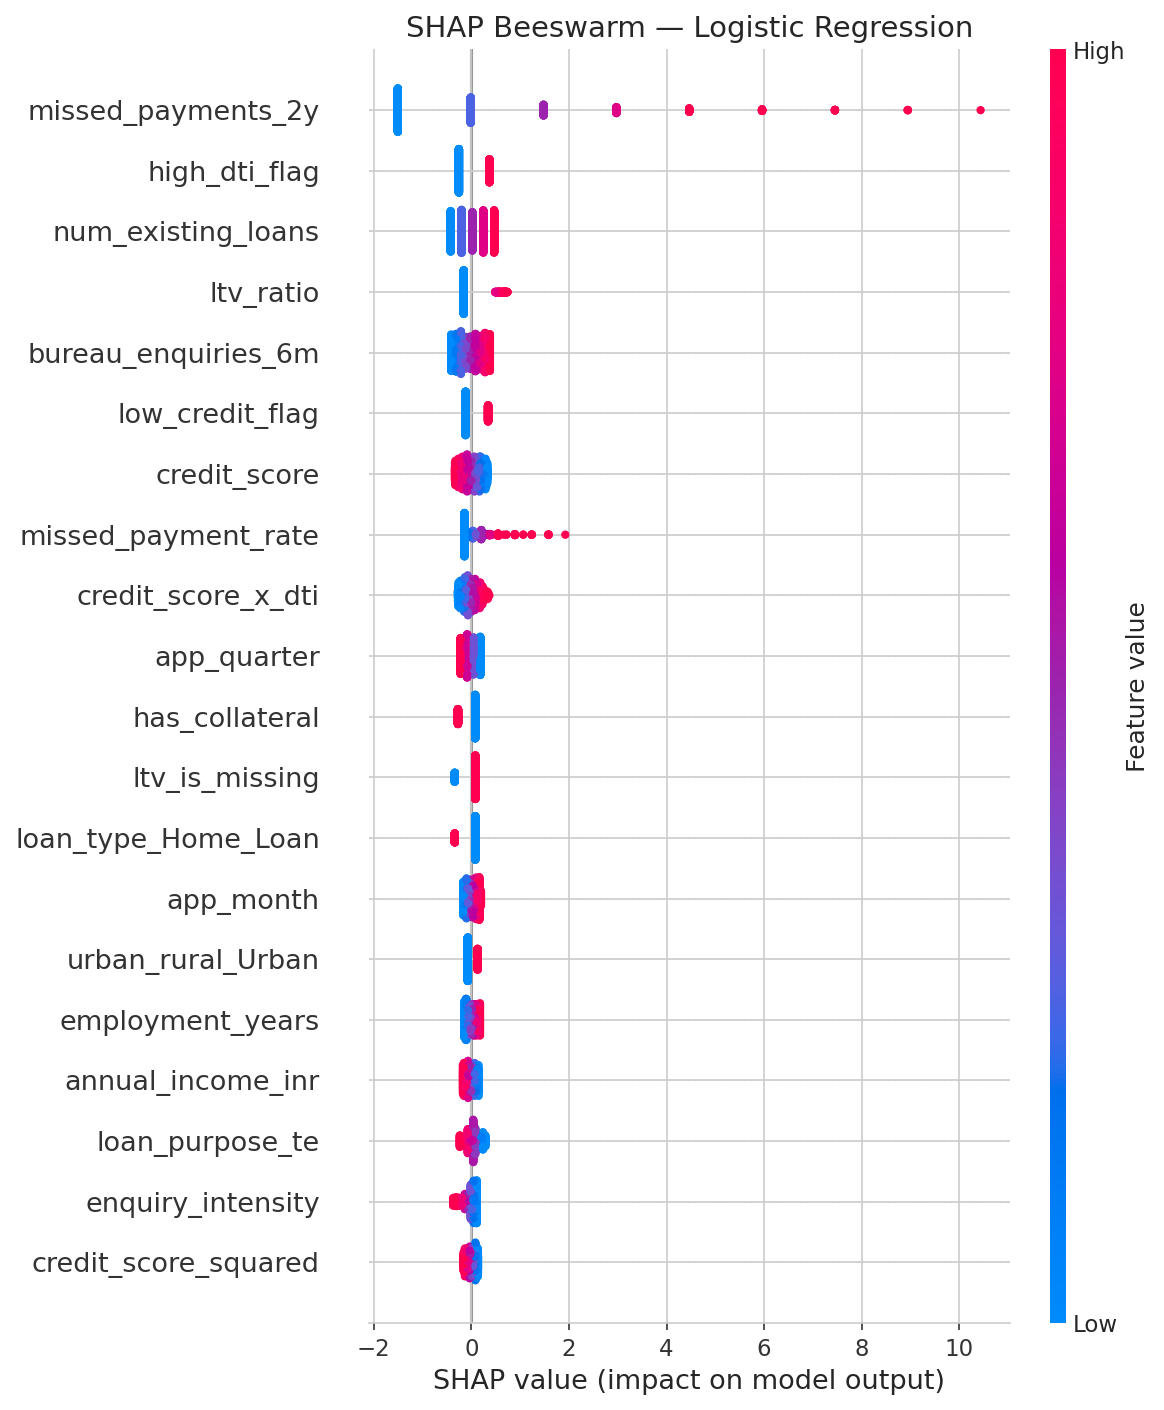

In [43]:
# Beeswarm summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_name}', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap/7_1_shap_beeswarm.png', bbox_inches='tight')
plt.show()

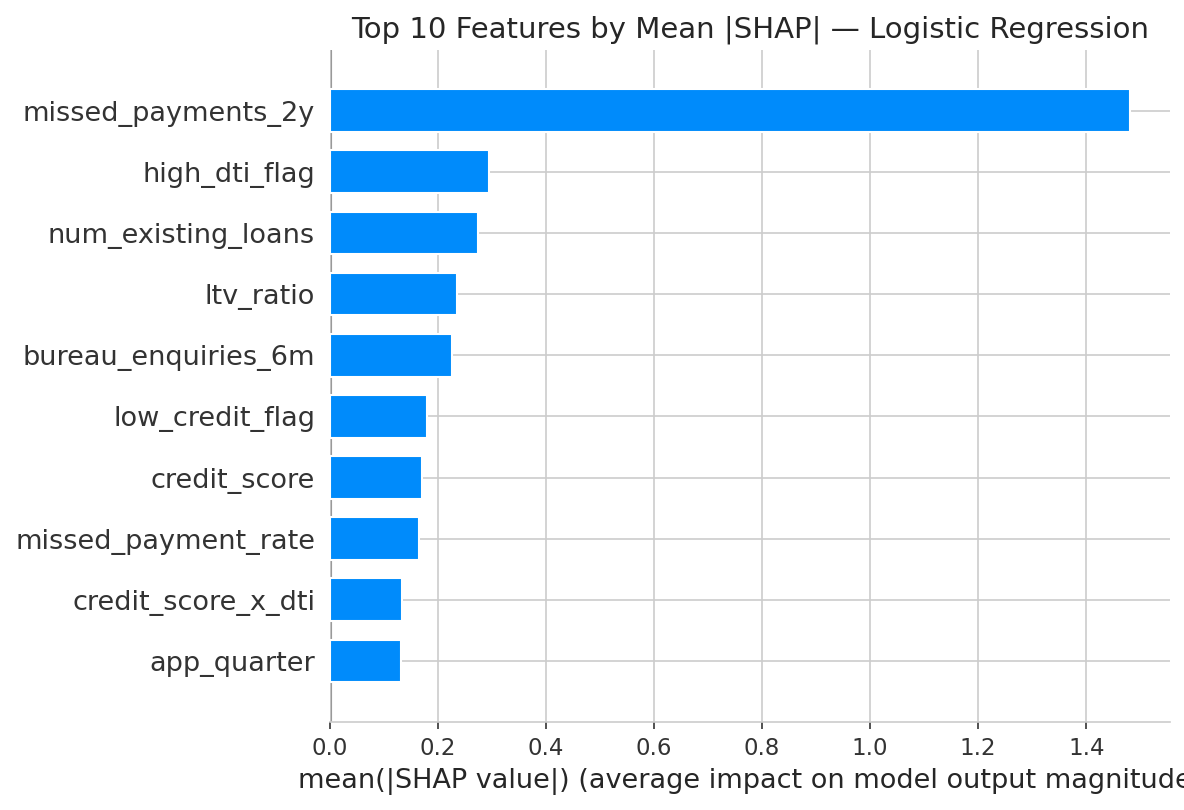

In [44]:
# Bar chart — top 10 features
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols, plot_type='bar',
                  show=False, max_display=10)
plt.title(f'Top 10 Features by Mean |SHAP| — {best_name}', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap/7_1_shap_top10_bar.png', bbox_inches='tight')
plt.show()

### 7.2 — Individual SHAP Waterfall Plots (Task 4.2)


  Obvious Default — P(default)=1.000
  Actual label: 1


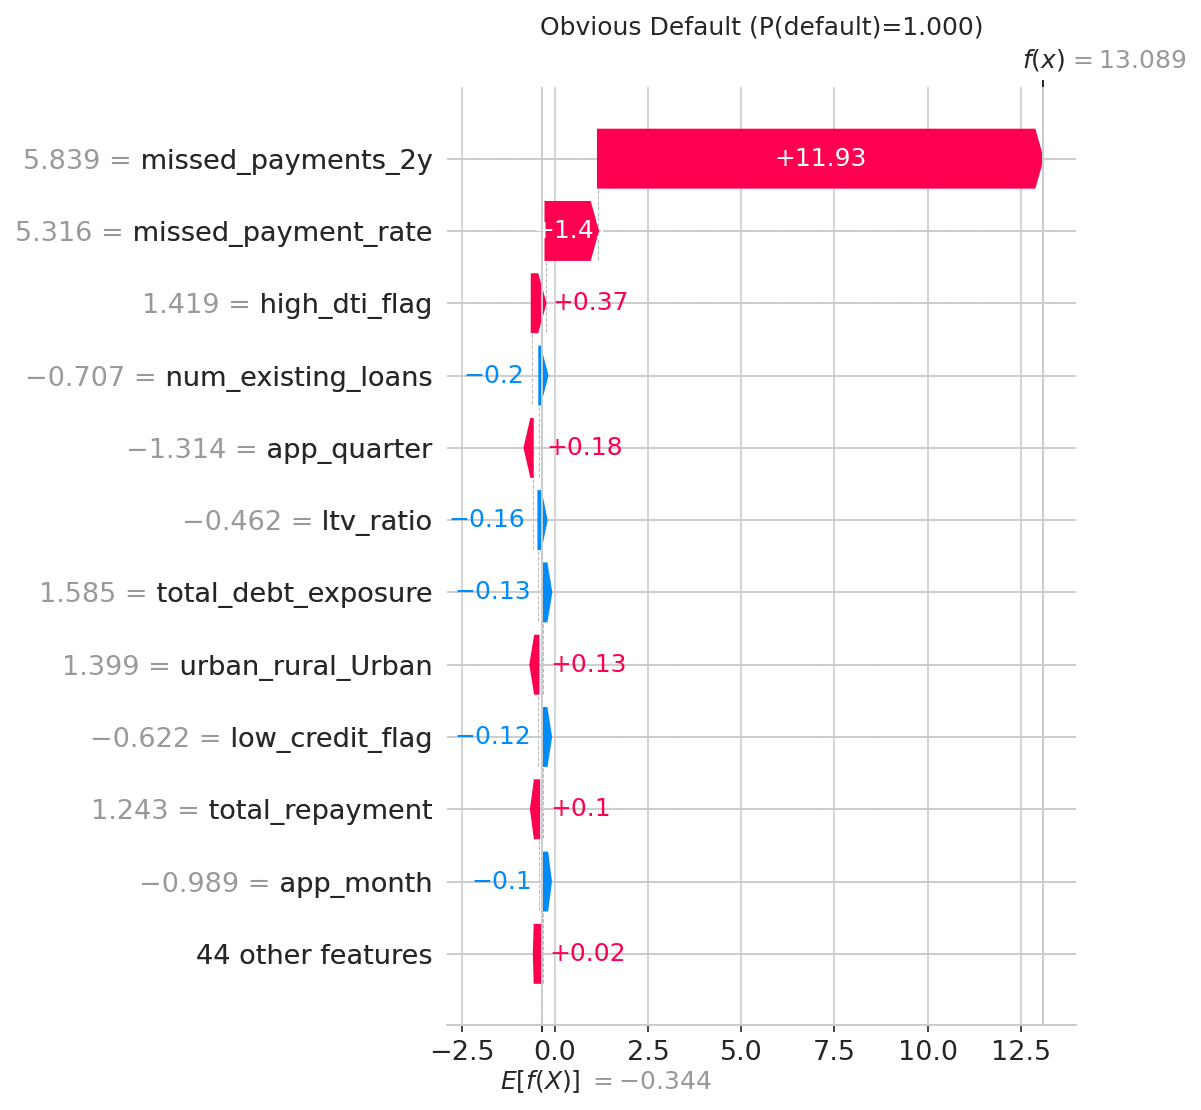


  Borderline Default — P(default)=0.500
  Actual label: 1


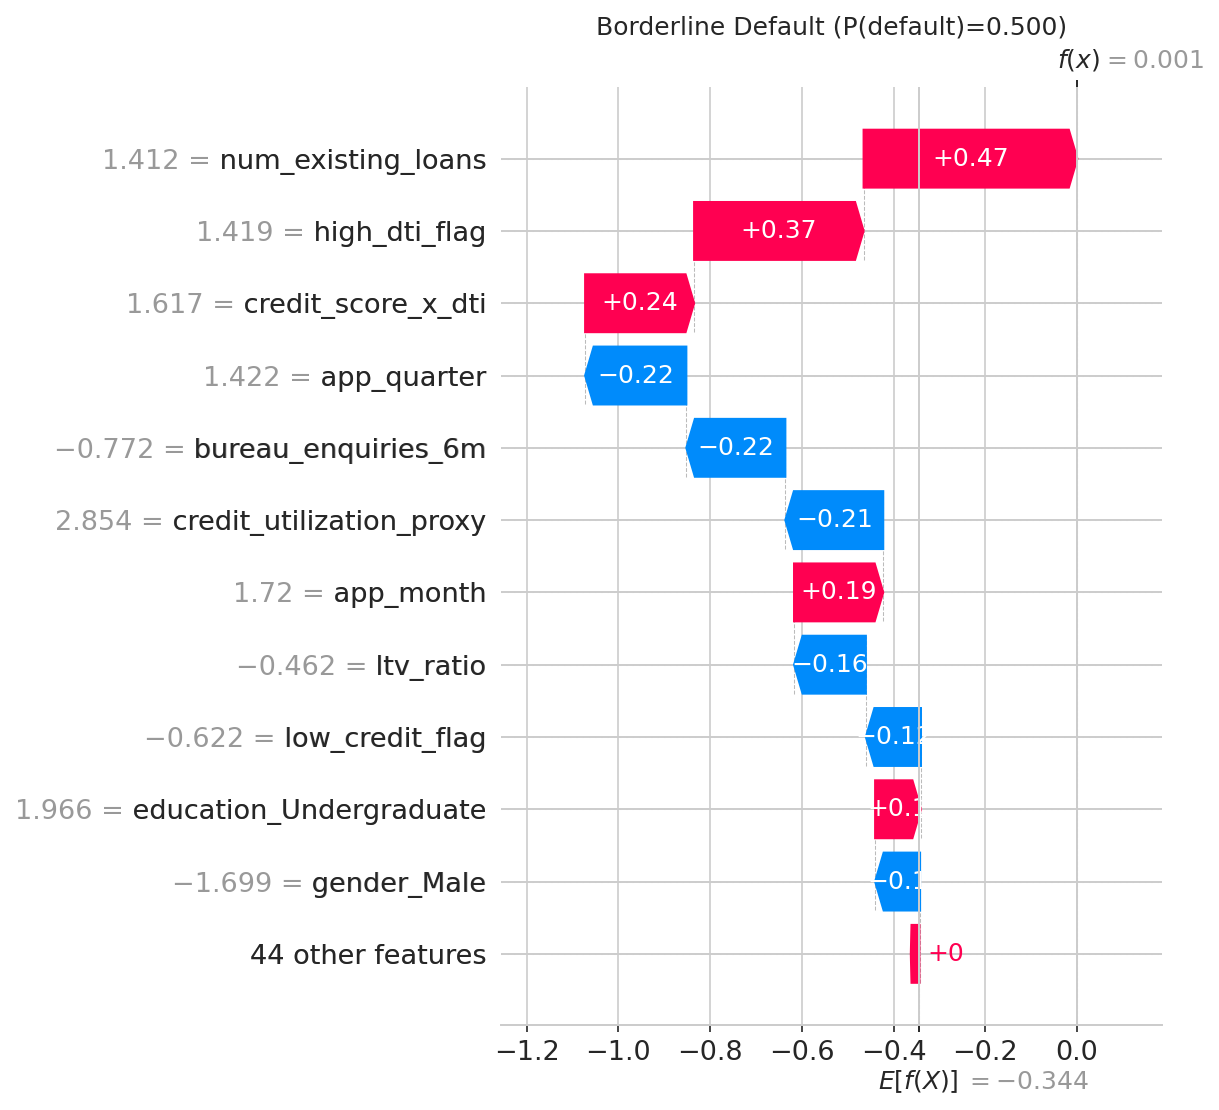


  Obvious Non-Default — P(default)=0.016
  Actual label: 0


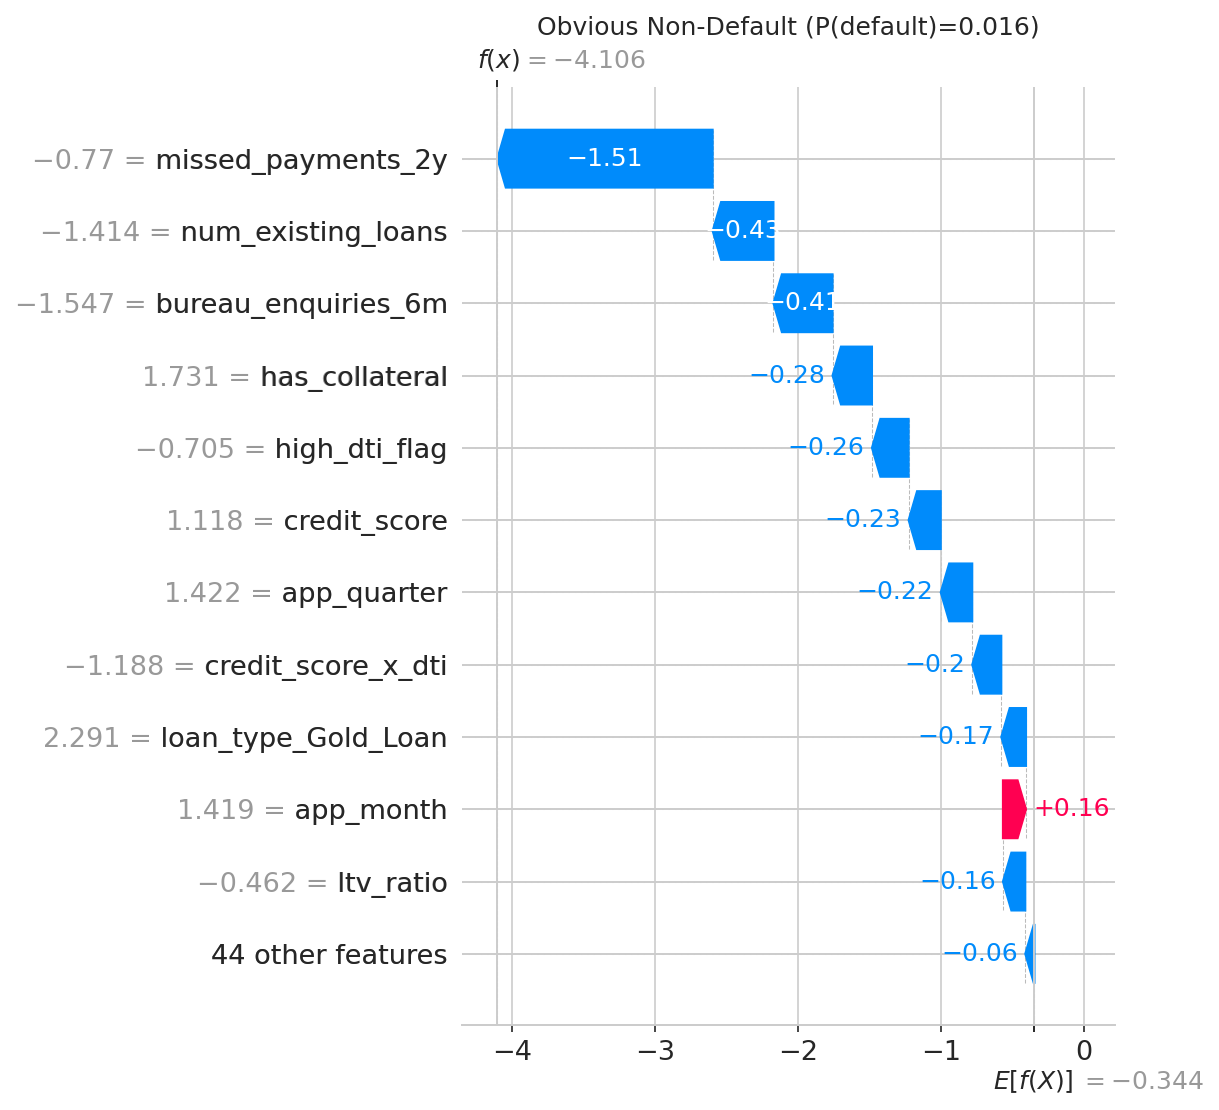


  Borderline Non-Default — P(default)=0.500
  Actual label: 0


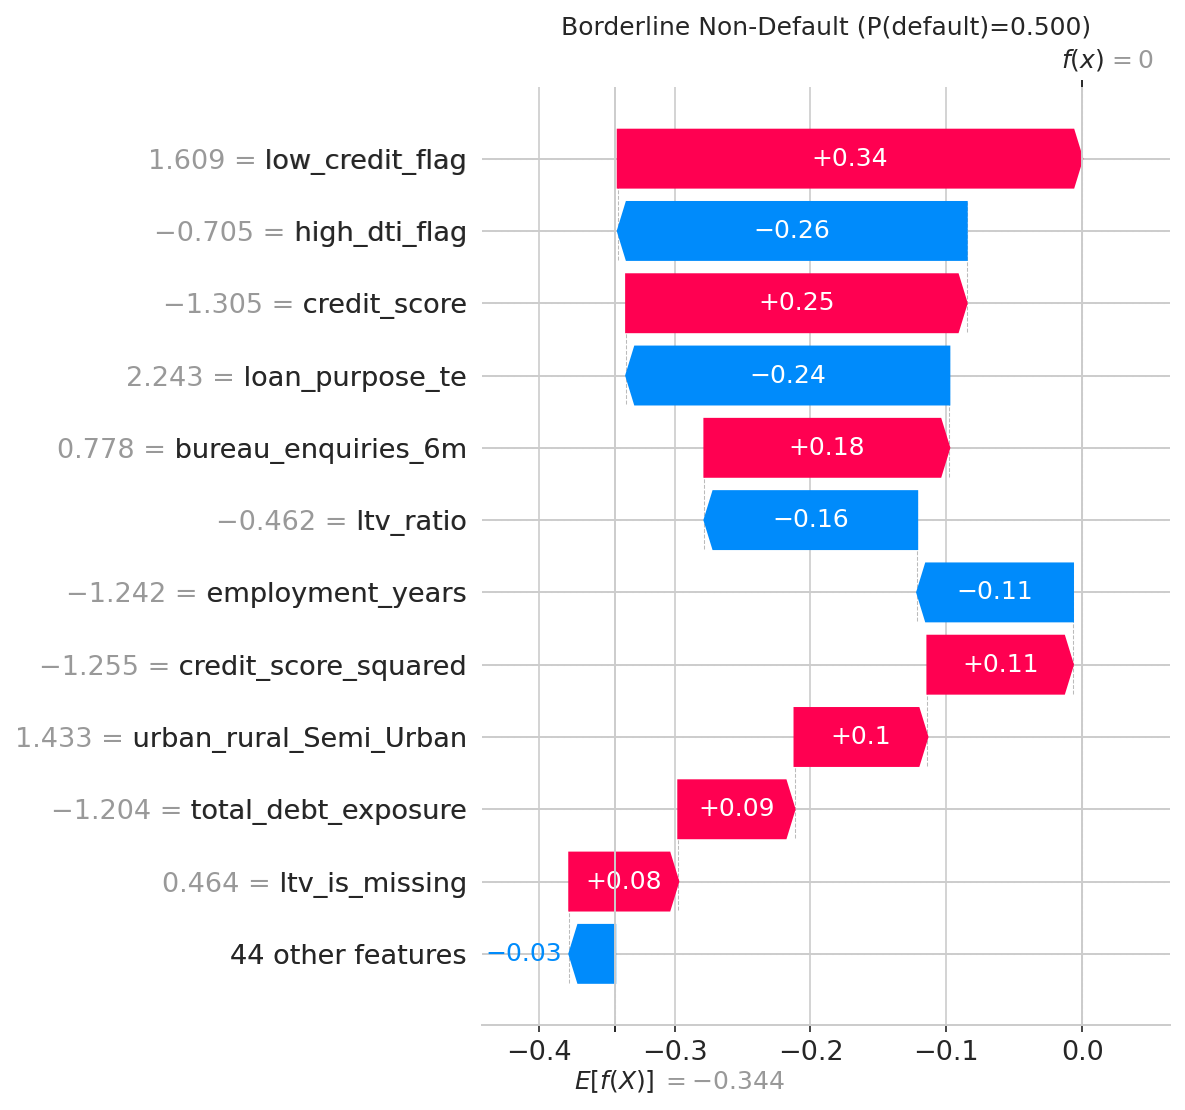

In [45]:
# Get predictions for all train samples
train_proba_all = final_model.predict_proba(X_train_scaled.values)[:, 1]

# Identify 4 interesting applicants
defaulters = np.where(y_train.values == 1)[0]
non_defaulters = np.where(y_train.values == 0)[0]

# Defaulters: one high prob (obvious), one moderate (borderline)
def_probs = train_proba_all[defaulters]
obvious_default_idx = defaulters[np.argmax(def_probs)]
# Borderline: closest to 0.5
borderline_default_idx = defaulters[np.argmin(np.abs(def_probs - 0.5))]

# Non-defaulters: one low prob (obvious), one moderate (borderline)
nondef_probs = train_proba_all[non_defaulters]
obvious_nondefault_idx = non_defaulters[np.argmin(nondef_probs)]
borderline_nondefault_idx = non_defaulters[np.argmin(np.abs(nondef_probs - 0.5))]

cases = [
    (obvious_default_idx,      "Obvious Default",       f"P(default)={train_proba_all[obvious_default_idx]:.3f}"),
    (borderline_default_idx,   "Borderline Default",    f"P(default)={train_proba_all[borderline_default_idx]:.3f}"),
    (obvious_nondefault_idx,   "Obvious Non-Default",   f"P(default)={train_proba_all[obvious_nondefault_idx]:.3f}"),
    (borderline_nondefault_idx,"Borderline Non-Default", f"P(default)={train_proba_all[borderline_nondefault_idx]:.3f}"),
]

# Compute SHAP for these specific individuals
for idx, title, prob_str in cases:
    row = X_train_scaled.iloc[[idx]]
    sv = explainer.shap_values(row)
    if isinstance(sv, list):
        sv = sv[1]

    # Create SHAP Explanation object for waterfall
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        base = explainer.expected_value

    explanation = shap.Explanation(
        values=sv[0],
        base_values=base,
        data=row.values[0],
        feature_names=feature_cols
    )

    print(f"\n{'='*50}")
    print(f"  {title} — {prob_str}")
    print(f"  Actual label: {int(y_train.values[idx])}")
    print(f"{'='*50}")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, show=False, max_display=12)
    plt.title(f'{title} ({prob_str})', fontsize=12)
    plt.tight_layout()
    fname = f"outputs/shap/7_2_waterfall_{title.lower().replace(' ', '_')}.png"
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

### 7.3 — Domain Alignment Discussion (Task 4.3)

**Expected vs Actual Top Features:**

In credit risk modeling, the most predictive features are typically:
- **Credit score** — the single strongest predictor of default risk
- **EMI-to-income ratio** — measures actual repayment burden relative to income
- **DTI ratio** — existing debt load
- **Missed payments (2y)** — behavioral signal of past default tendency
- **Savings-to-loan ratio** — liquidity buffer

Review the SHAP beeswarm plot above. The top features should align with domain expectations. If temporal features (`app_month`, `days_since_earliest`) or geographic features (`state_te`) rank unexpectedly high, this may indicate:
- Seasonal patterns in default (e.g., agricultural loan defaults post-harvest)
- Regional economic disparities affecting repayment capacity

**Fairness Concern — Gender:**
Check whether any gender-related one-hot encoded feature appears in the top 15 SHAP features. If gender has meaningful SHAP contribution, this is a fairness red flag — credit decisions should not discriminate by gender. Regulatory frameworks (RBI guidelines, Equal Credit Opportunity) require gender-neutral lending criteria. Consider removing gender features and retraining if its contribution is significant.

In [46]:
# Quantify gender SHAP contribution
gender_features = [f for f in feature_cols if 'gender' in f.lower()]
if gender_features:
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    shap_df = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap})
    shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    total_shap = shap_df['mean_abs_shap'].sum()
    for gf in gender_features:
        gf_shap = shap_df[shap_df['feature'] == gf]['mean_abs_shap'].values
        if len(gf_shap) > 0:
            rank = shap_df[shap_df['feature'] == gf].index[0] + 1
            pct = gf_shap[0] / total_shap * 100
            print(f"Gender feature '{gf}': rank {rank}/{len(feature_cols)}, "
                  f"contributes {pct:.2f}% of total SHAP importance")
            if rank <= 15:
                print("  ⚠ FAIRNESS CONCERN: Gender is among top 15 features!")
            else:
                print("  ✓ Gender has low importance — not a major fairness concern.")
else:
    print("No gender features found in the model.")

Gender feature 'gender_Male': rank 29/55, contributes 0.89% of total SHAP importance
  ✓ Gender has low importance — not a major fairness concern.


---
## Section 8: Business Summary (Task 5.1)

In [48]:

if TEST_HAS_TARGET and 'test_proba' in dir():
    pred_df = pd.DataFrame({
        'loan_id': test_loan_ids if test_loan_ids is not None else range(len(test_proba)),
        'predicted_probability': test_proba,
        'predicted_class': test_preds,
    })
    pred_df.to_csv('outputs/predictions/test_predictions.csv', index=False)
    print(f"✅ Test predictions saved: outputs/predictions/test_predictions.csv ({len(pred_df)} rows)")
else:
    print("⚠ Test predictions not generated (no target in test or model not evaluated on test).")

if 'final_model' in dir():
    joblib.dump(final_model, 'outputs/model/best_model.pkl')
    print(f"✅ Model saved: outputs/model/best_model.pkl ({best_name})")

import glob
plots = glob.glob('outputs/plots/*.png')
shap_plots = glob.glob('outputs/shap/*.png')
print(f"\n✅ Plots saved: {len(plots)} in outputs/plots/")
for p in sorted(plots):
    print(f"   {p}")
print(f"\n✅ SHAP plots saved: {len(shap_plots)} in outputs/shap/")
for p in sorted(shap_plots):
    print(f"   {p}")

print("\n" + "=" * 60)
print("  ALL DONE — Notebook execution complete!")
print("=" * 60)

⚠ Test predictions not generated (no target in test or model not evaluated on test).
✅ Model saved: outputs/model/best_model.pkl (Logistic Regression)

✅ Plots saved: 9 in outputs/plots/
   outputs/plots/3_1_default_by_category.png
   outputs/plots/3_2_continuous_distributions.png
   outputs/plots/3_3_credit_band_analysis.png
   outputs/plots/3_4_temporal_analysis.png
   outputs/plots/3_5_correlation_heatmap.png
   outputs/plots/5_clustermap.png
   outputs/plots/6_5_roc_pr_curves.png
   outputs/plots/6_7_ks_curve.png
   outputs/plots/6_8_threshold_optimization.png

✅ SHAP plots saved: 6 in outputs/shap/
   outputs/shap/7_1_shap_beeswarm.png
   outputs/shap/7_1_shap_top10_bar.png
   outputs/shap/7_2_waterfall_borderline_default.png
   outputs/shap/7_2_waterfall_borderline_non-default.png
   outputs/shap/7_2_waterfall_obvious_default.png
   outputs/shap/7_2_waterfall_obvious_non-default.png

  ALL DONE — Notebook execution complete!
